<a href="https://colab.research.google.com/github/shubhamtrehan11-alt/Full-Institutional-Multi-Asset-Backtesting-Platform/blob/main/Backtesting_Platform.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install yfinance pandas-datareader cvxpy plotly scikit-learn statsmodels arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 14.4 MB/s eta 0:00:00


✅ Platform configured — Universe: 25 equities, 10 ETFs, 5 futures

  INSTITUTIONAL MULTI-ASSET BACKTESTING PLATFORM

📡 STEP 1: Data Pipeline


   ✓ 39 assets | 2890 days | 8 macro series

📊 STEP 2: Signal Engine (Factor Alpha)
   ✓ Mean IC: 0.0140 | ICIR: 0.05

💸 STEP 3: Transaction Cost Model
   ✓ Commission: 1.0 bps | Slippage: 2.0 bps | Market Impact: Almgren-Chriss √-model

🎯 STEP 4: Portfolio Optimizer
   ✓ Method: signal_weighted | Max position: 5% | Max sector: 25%

⚙️  STEP 5: Running Backtest...


   ✓ Backtest complete

📈 STEP 6: Performance Analytics

   ─────────────────────────────────────────────
   METRIC                                  VALUE
   ─────────────────────────────────────────────
   Ann. Return (%)                          5.26
   Ann. Volatility (%)                      8.93
   Sharpe Ratio                             0.06
   Max Drawdown (%)                       -21.85
   Alpha (Ann. %)                          -1.65
   Beta                                     0.22
   Information Ratio                       -0.20
   ─────────────────────────────────────────────

🛡️  STEP 7: Risk Analysis
   ✓ Parametric VaR (99%, 1D): 1.29%
   ✓ Historical  VaR (99%, 1D): 2.02%
   ✓ Systematic risk: 18.9% | Idiosyncratic: 81.1%
   ✓ GFC_2008                 : +0.0%
   ✓ COVID_Crash_2020         : -34.9%
   ✓ Dot_com_2000             : +0.0%
   ✓ Flash_Crash_2010         : +0.0%
   ✓ Russia_2022              : -0.6%

🎨 STEP 8: Generating Visualizations...
   ✓ All charts rend

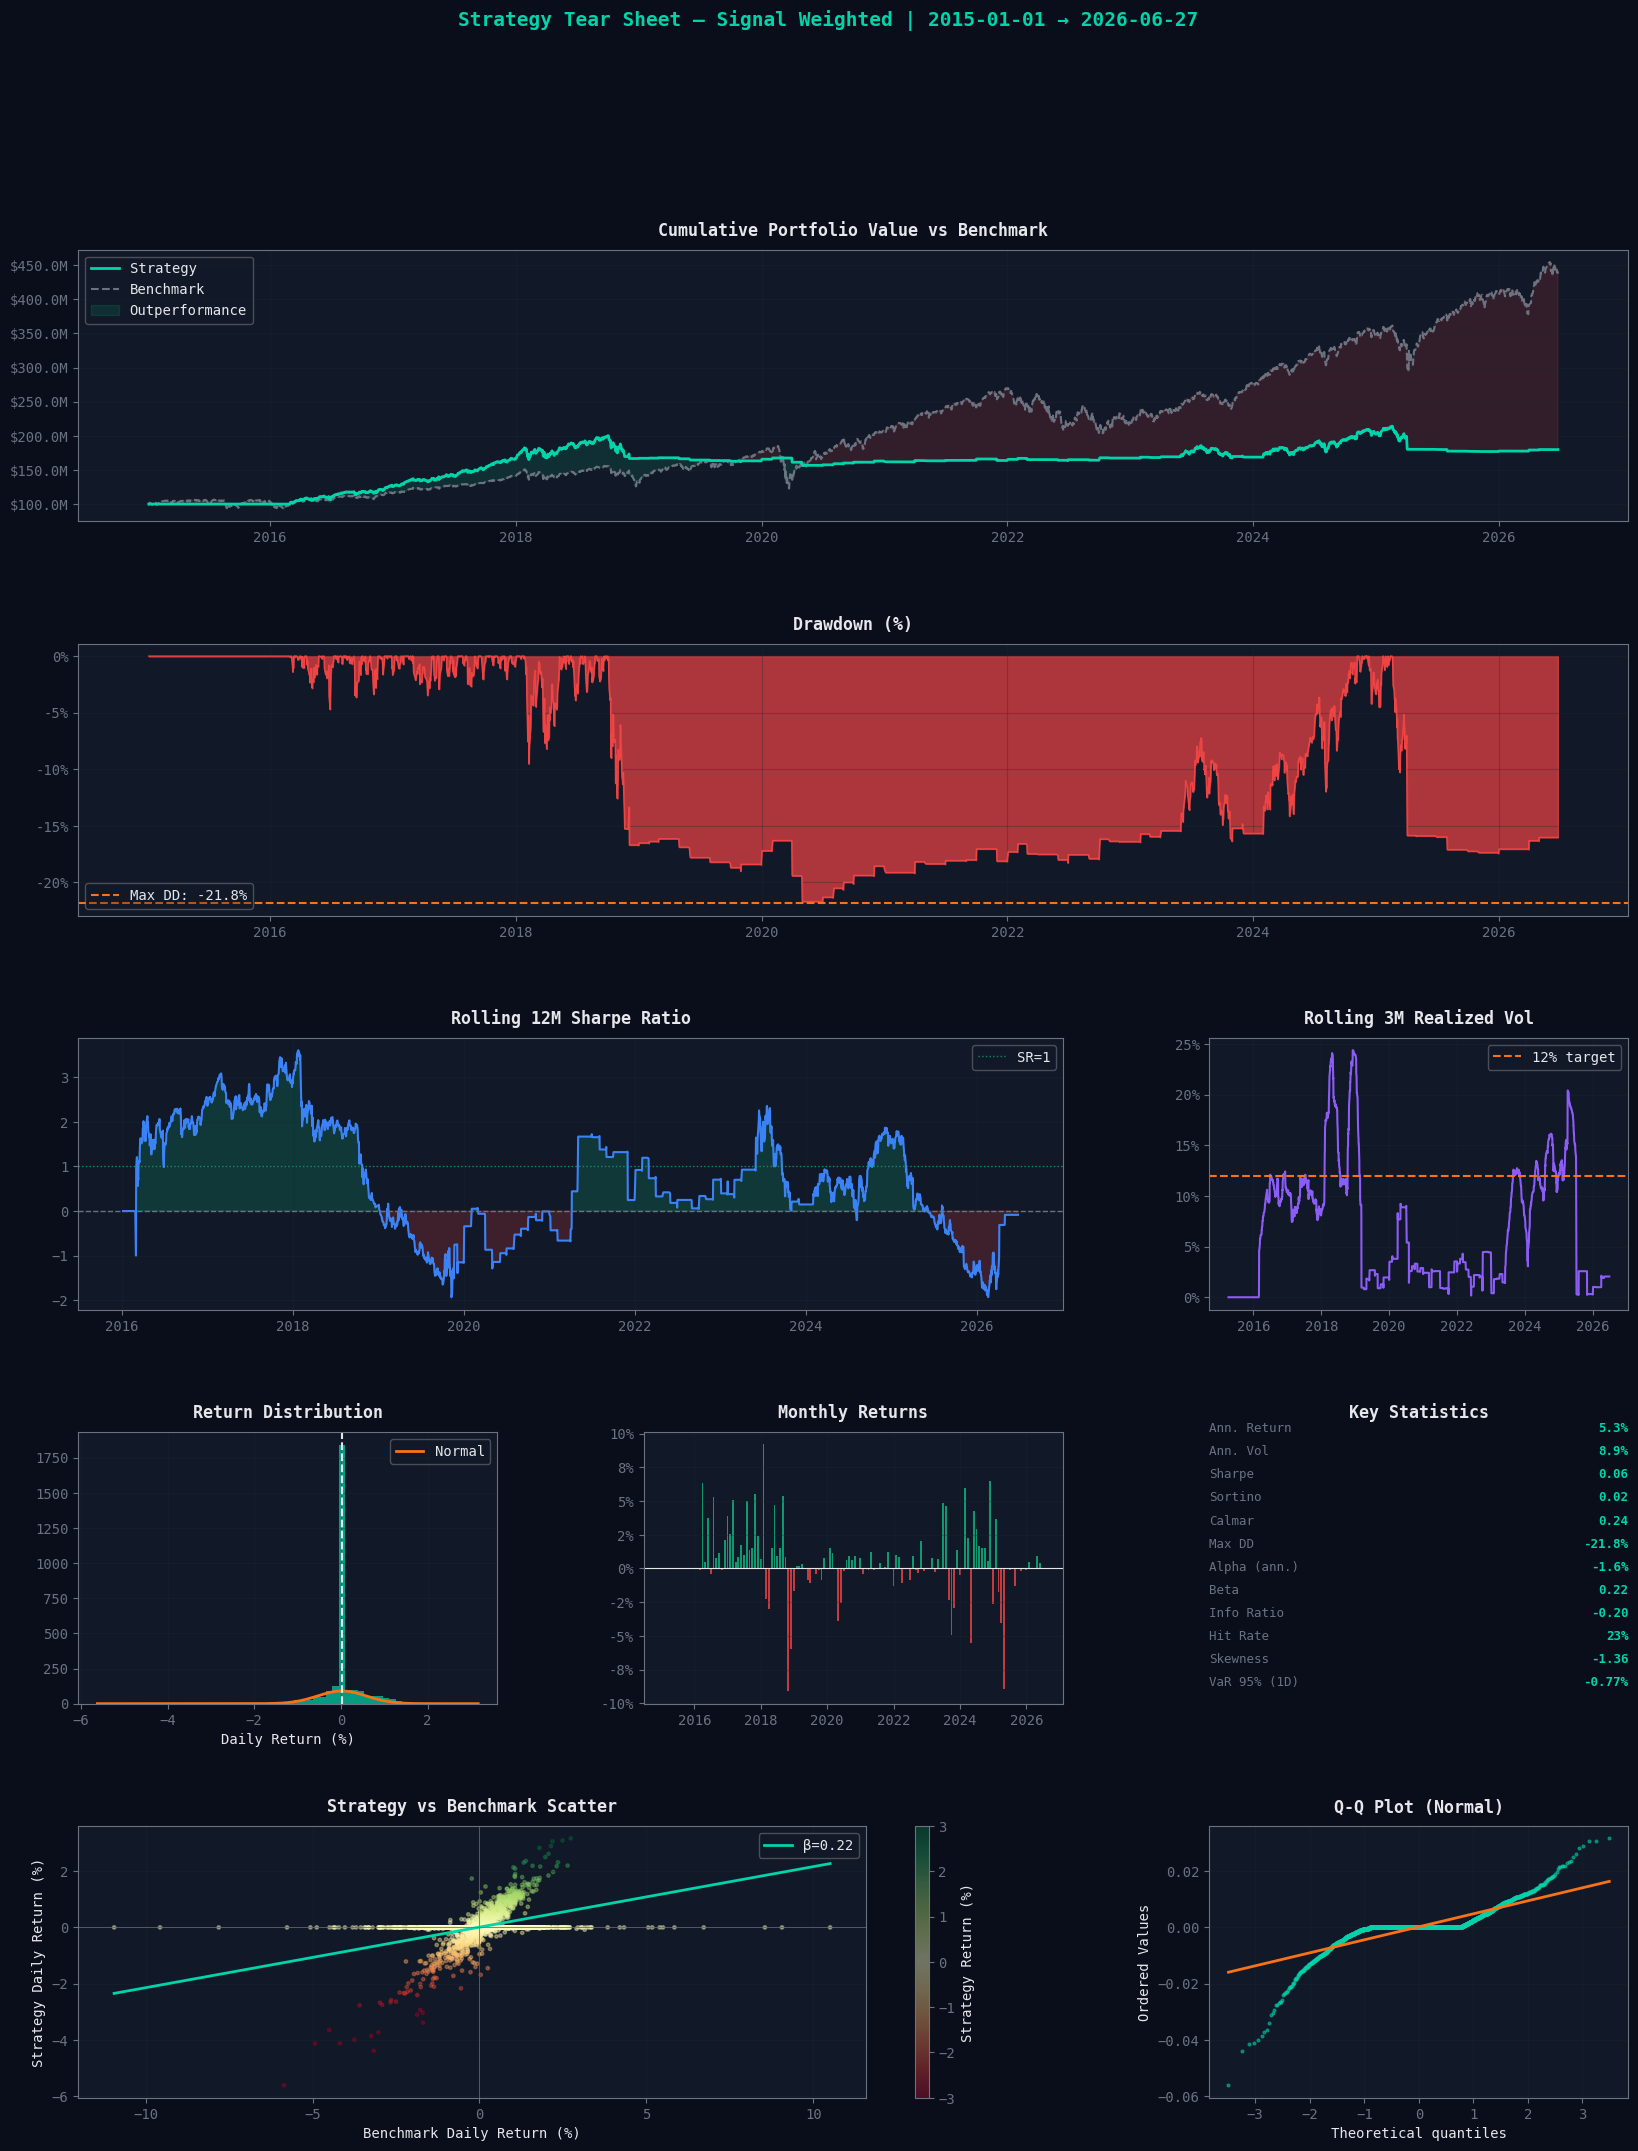

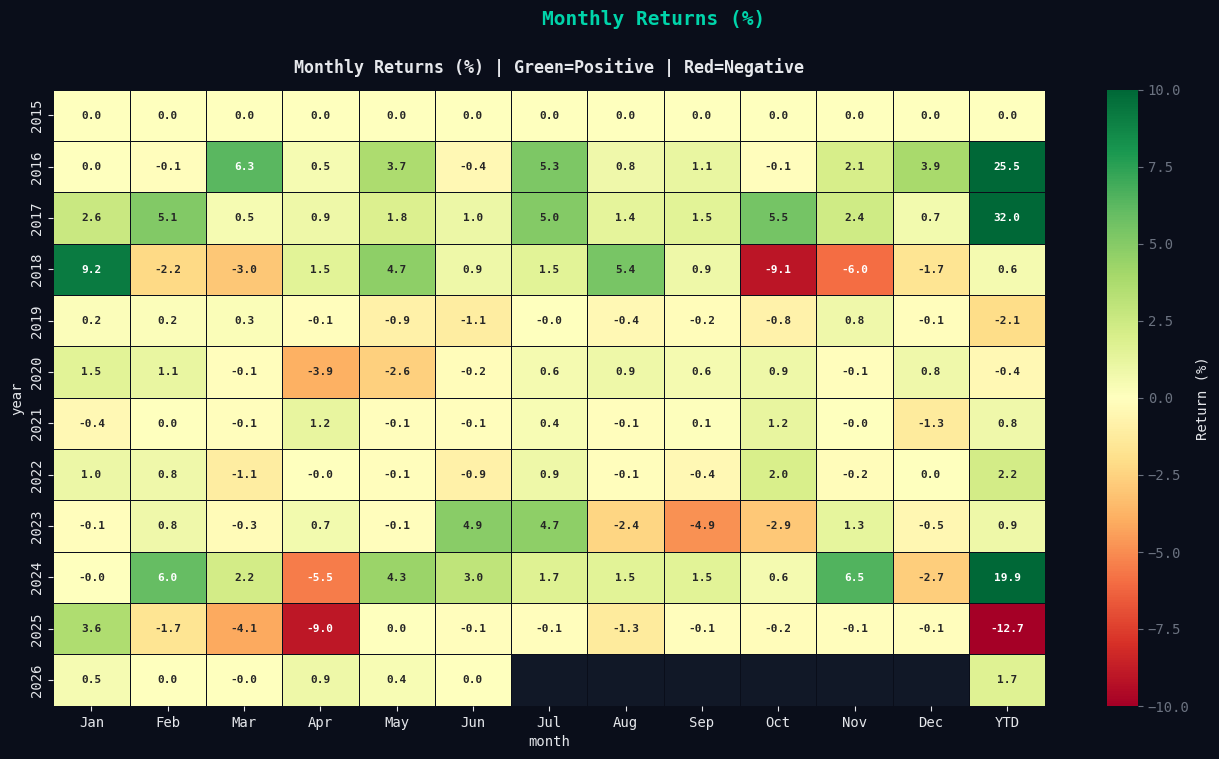

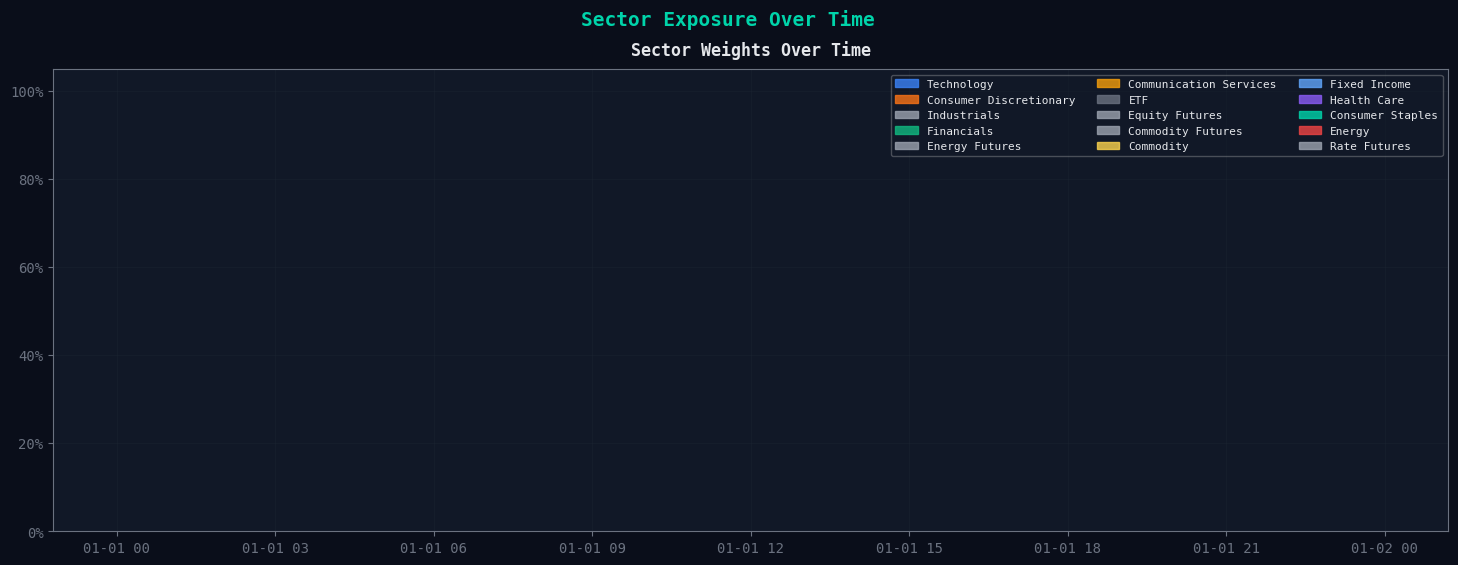

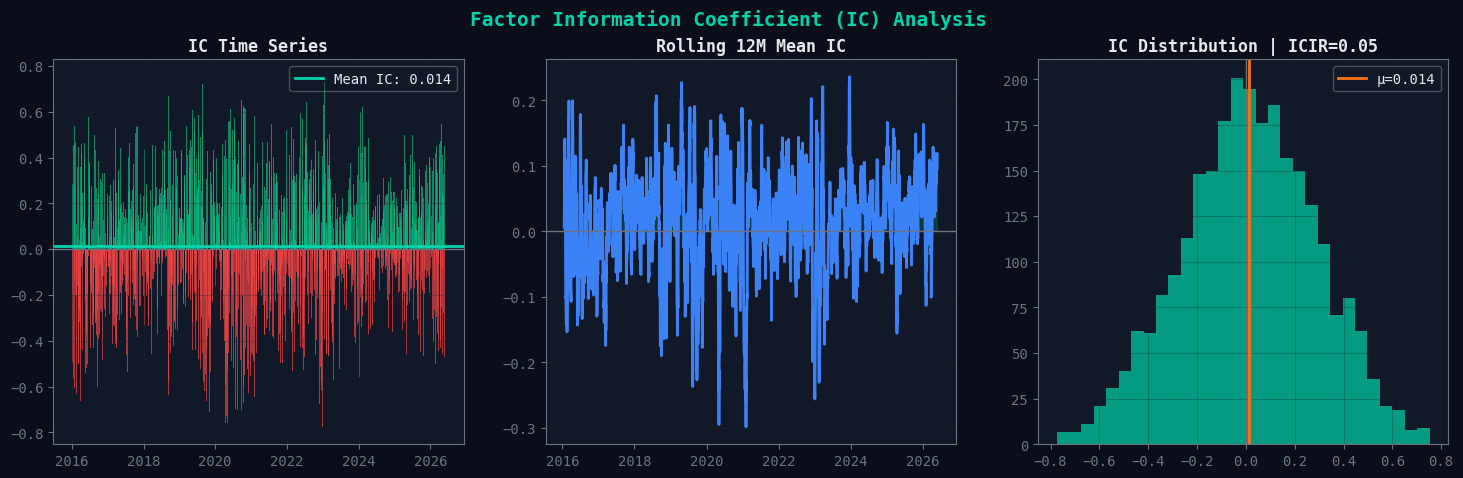

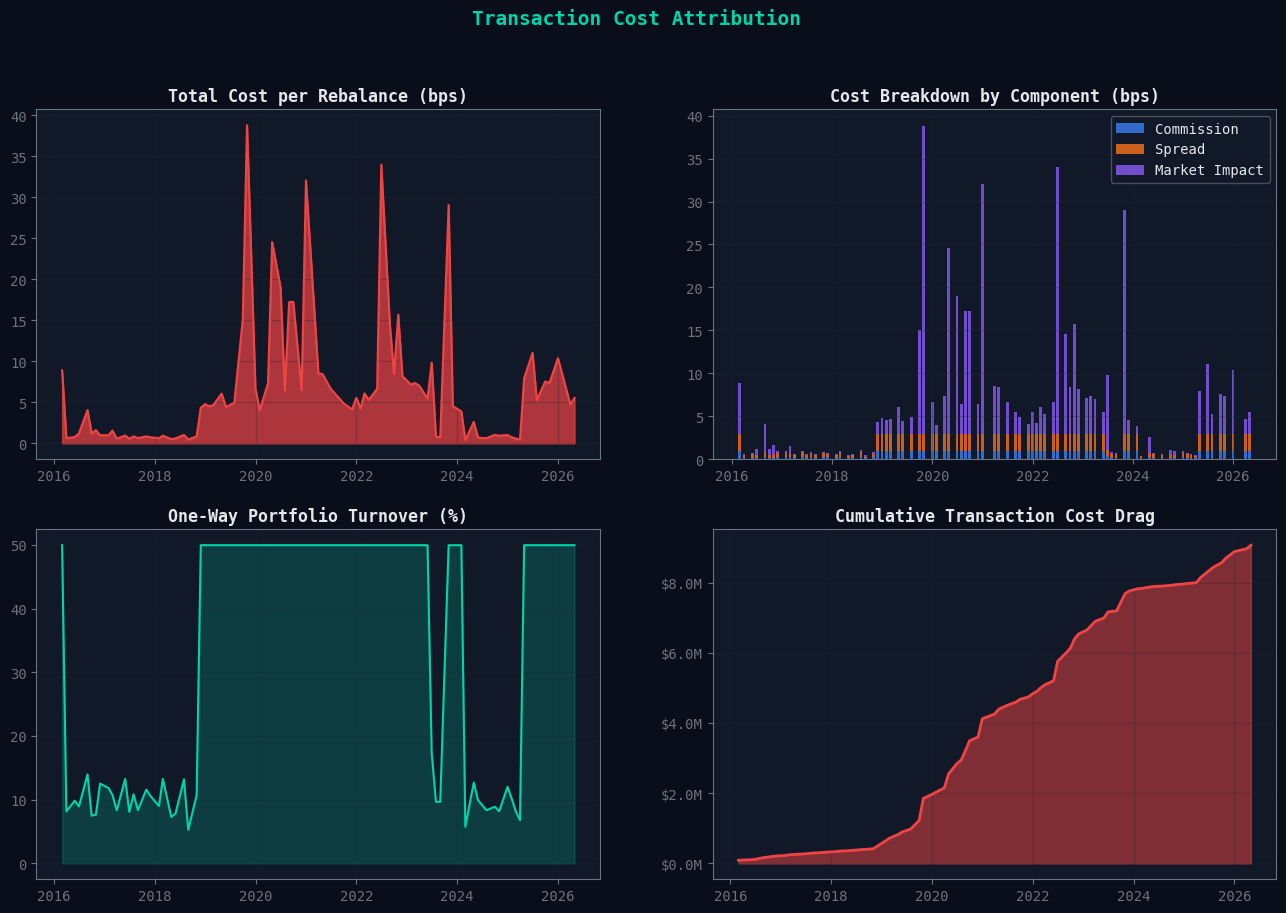

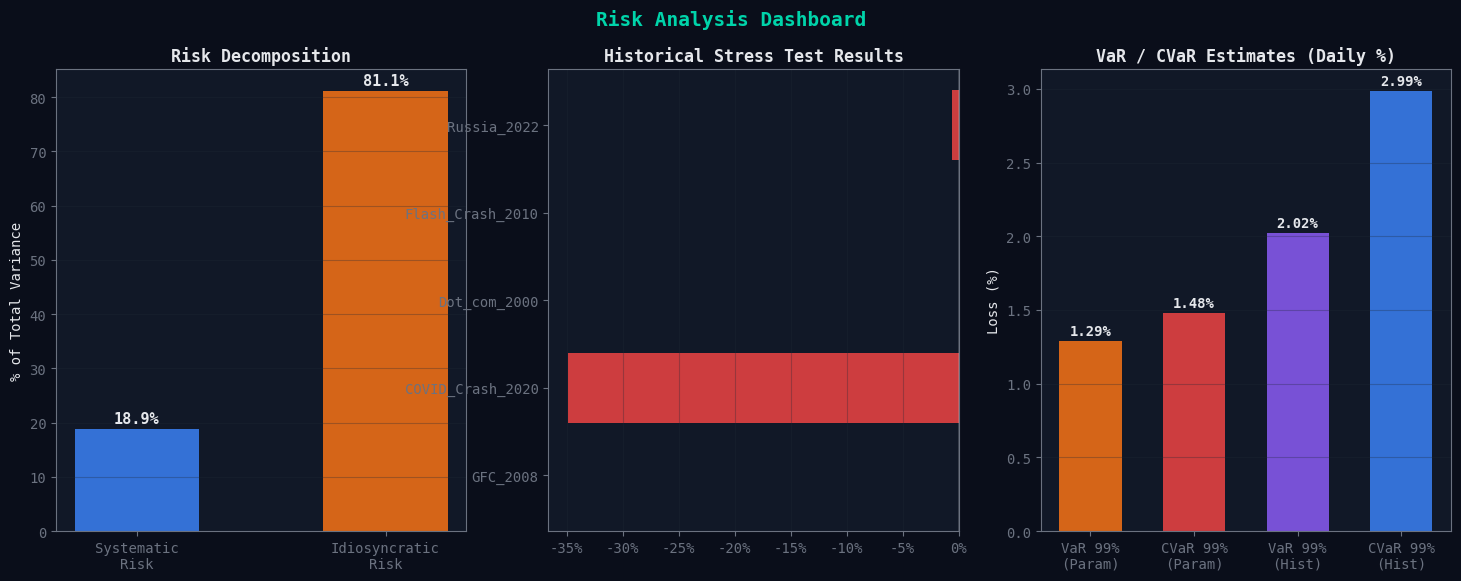


✅ Platform run complete. Access results dict for downstream analysis.
   results.keys(): ['config', 'prices', 'returns', 'macro', 'signals', 'ic_series', 'backtest', 'metrics', 'monthly_table', 'risk_decomp', 'var_param', 'var_hist', 'stress', 'figures']


In [2]:
#!/usr/bin/env python3
"""
================================================================================
 INSTITUTIONAL MULTI-ASSET BACKTESTING PLATFORM
================================================================================
 Author      : Senior Quantitative Developer
 Version     : 1.0.0
 Python      : 3.9+
 Description : Professional-grade research platform supporting equities, ETFs,
               futures, factor investing, and risk management — modeled after
               infrastructure used at Citadel, Millennium, and Point72.
================================================================================
 ARCHITECTURE OVERVIEW
 ─────────────────────
  1. Data Pipeline          → Polygon, FRED, Yahoo Finance, SEC APIs
  2. Signal Engine          → Momentum, Value, Quality, Low-Vol factors
  3. Transaction Cost Model → Bid-ask spread + market impact (Almgren-Chriss)
  4. Portfolio Optimizer    → Mean-Variance, Risk-Parity, Black-Litterman
  5. Risk Engine            → VaR, CVaR, Factor Risk Decomposition
  6. Analytics Dashboard    → Tear sheets, drawdown, exposure, attribution
================================================================================
"""

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 1 — INSTALL DEPENDENCIES                                              ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
"""
Run in Colab:
!pip install yfinance pandas-datareader fredapi cvxpy vectorbt pyfolio-reloaded
!pip install plotly kaleido scipy statsmodels arch requests tqdm colorama
!pip install pandas numpy matplotlib seaborn scikit-learn
"""


# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 2 — IMPORTS & GLOBAL CONFIGURATION                                    ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import os
import sys
import json
import time
import logging
import warnings
import requests
from io import BytesIO
from datetime import datetime, timedelta
from typing import Dict, List, Optional, Tuple, Union
from dataclasses import dataclass, field
from enum import Enum

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

from scipy import stats
from scipy.optimize import minimize
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import yfinance as yf

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")
log = logging.getLogger(__name__)

# ── Color palette (Bloomberg Terminal inspired) ────────────────────────────────
COLORS = {
    "bg_dark":    "#0A0E1A",
    "bg_panel":   "#111827",
    "accent":     "#00D4AA",
    "accent2":    "#F59E0B",
    "danger":     "#EF4444",
    "text":       "#E5E7EB",
    "muted":      "#6B7280",
    "blue":       "#3B82F6",
    "purple":     "#8B5CF6",
    "green":      "#10B981",
    "orange":     "#F97316",
}

plt.rcParams.update({
    "figure.facecolor":  COLORS["bg_dark"],
    "axes.facecolor":    COLORS["bg_panel"],
    "axes.edgecolor":    COLORS["muted"],
    "axes.labelcolor":   COLORS["text"],
    "text.color":        COLORS["text"],
    "xtick.color":       COLORS["muted"],
    "ytick.color":       COLORS["muted"],
    "grid.color":        "#1F2937",
    "grid.alpha":        0.5,
    "font.family":       "monospace",
    "font.size":         10,
    "axes.titlesize":    12,
    "axes.titleweight":  "bold",
})


# ── Platform configuration dataclass ──────────────────────────────────────────
@dataclass
class PlatformConfig:
    """Central configuration for the entire research platform."""

    # Universe
    equity_universe: List[str] = field(default_factory=lambda: [
        "AAPL", "MSFT", "GOOGL", "AMZN", "NVDA", "META", "TSLA", "BRK-B",
        "JPM", "JNJ", "V", "PG", "MA", "HD", "UNH", "DIS", "PYPL", "ADBE",
        "NFLX", "CRM", "INTC", "AMD", "BA", "GS", "MS",
    ])
    etf_universe: List[str] = field(default_factory=lambda: [
        "SPY", "QQQ", "IWM", "GLD", "TLT", "HYG", "EEM", "VXX", "XLE", "XLF",
    ])
    futures_proxies: List[str] = field(default_factory=lambda: [
        "ES=F", "NQ=F", "GC=F", "CL=F", "ZN=F",
    ])

    # Backtest window
    start_date: str = "2015-01-01"
    end_date:   str = datetime.today().strftime("%Y-%m-%d")

    # Capital & costs
    initial_capital:    float = 100_000_000.0   # $100M (institutional)
    max_position_size:  float = 0.05            # 5% per name
    max_sector_weight:  float = 0.25            # 25% per sector
    commission_bps:     float = 1.0             # 1 bps commission
    slippage_bps:       float = 2.0             # 2 bps slippage
    borrow_rate_bps:    float = 25.0            # 25 bps short borrow

    # Factor model
    factor_lookback_days:    int = 252
    momentum_lookback_days:  int = 252
    rebalance_frequency:     str = "M"          # Monthly
    signal_decay_halflife:   int = 20

    # Risk limits
    max_portfolio_vol:  float = 0.12            # 12% annualized vol target
    var_confidence:     float = 0.99
    max_drawdown_limit: float = 0.15            # Halt at -15% drawdown

    # API keys (set via environment or Colab secrets)
    polygon_api_key:  str = field(default_factory=lambda: os.getenv("POLYGON_API_KEY", "demo"))
    fred_api_key:     str = field(default_factory=lambda: os.getenv("FRED_API_KEY", "demo"))

CONFIG = PlatformConfig()
print(f"✅ Platform configured — Universe: {len(CONFIG.equity_universe)} equities, "
      f"{len(CONFIG.etf_universe)} ETFs, {len(CONFIG.futures_proxies)} futures")


# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 3 — DATA PIPELINE                                                     ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

class DataPipeline:
    """
    Institutional-grade data ingestion layer.

    Handles:
    - Price/volume data via Yahoo Finance (free) or Polygon (premium)
    - Macro data via FRED API
    - Fundamental / factor data derived from price series
    - Data quality checks and corporate action adjustments
    """

    def __init__(self, config: PlatformConfig):
        self.config = config
        self._price_cache: Dict[str, pd.DataFrame] = {}

    # ── Core price download ────────────────────────────────────────────────────
    def fetch_prices(
        self,
        tickers: List[str],
        start: Optional[str] = None,
        end:   Optional[str] = None,
        retries: int = 3,
    ) -> pd.DataFrame:
        """
        Download adjusted OHLCV data. Falls back ticker-by-ticker on errors.
        Returns a MultiIndex DataFrame: (Date, Ticker) × (Open/High/Low/Close/Volume).
        """
        start = start or self.config.start_date
        end   = end   or self.config.end_date

        log.info(f"Fetching prices for {len(tickers)} tickers [{start} → {end}]")

        for attempt in range(retries):
            try:
                raw = yf.download(
                    tickers,
                    start=start,
                    end=end,
                    auto_adjust=True,
                    progress=False,
                    threads=True,
                )
                break
            except Exception as exc:
                log.warning(f"Download attempt {attempt+1} failed: {exc}")
                time.sleep(2 ** attempt)
        else:
            raise RuntimeError("Data download failed after all retries.")

        # ── Flatten MultiIndex columns ─────────────────────────────────────────
        if isinstance(raw.columns, pd.MultiIndex):
            close  = raw["Close"].copy()
            volume = raw["Volume"].copy()
        else:
            # Single ticker — yfinance returns flat columns
            close  = raw[["Close"]].rename(columns={"Close": tickers[0]})
            volume = raw[["Volume"]].rename(columns={"Volume": tickers[0]})

        # ── Data quality: drop tickers with >20% missing ───────────────────────
        missing_pct = close.isna().mean()
        bad_tickers = missing_pct[missing_pct > 0.20].index.tolist()
        if bad_tickers:
            log.warning(f"Dropping {len(bad_tickers)} tickers with >20% missing: {bad_tickers}")
            close  = close.drop(columns=bad_tickers)
            volume = volume.drop(columns=bad_tickers, errors="ignore")

        close  = close.ffill().bfill()
        volume = volume.fillna(0)

        result = pd.concat({"close": close, "volume": volume}, axis=1)
        log.info(f"✅ Price data loaded: {result.shape[0]} days × {close.shape[1]} tickers")
        return result

    # ── Compute returns ────────────────────────────────────────────────────────
    def compute_returns(self, prices: pd.DataFrame) -> pd.DataFrame:
        """Compute daily log returns from close prices."""
        close = prices["close"] if isinstance(prices.columns, pd.MultiIndex) else prices
        log_returns = np.log(close / close.shift(1)).dropna()
        return log_returns

    # ── FRED macro data ────────────────────────────────────────────────────────
    def fetch_macro_data(self) -> pd.DataFrame:
        """
        Fetch key macro series from FRED via pandas_datareader.
        Falls back to synthetic data if API key not available.
        """
        series_map = {
            "DGS10":    "10Y_Treasury",
            "DGS2":     "2Y_Treasury",
            "T10Y2Y":   "Yield_Curve",
            "VIXCLS":   "VIX",
            "DCOILWTICO": "Crude_Oil",
            "DTWEXBGS": "DXY",
            "UNRATE":   "Unemployment",
            "CPIAUCSL": "CPI",
        }

        macro_frames = {}
        for fred_id, label in series_map.items():
            try:
                import pandas_datareader.data as web
                s = web.DataReader(
                    fred_id, "fred",
                    start=self.config.start_date,
                    end=self.config.end_date,
                )
                macro_frames[label] = s.squeeze()
            except Exception:
                # Generate synthetic proxy when FRED is unavailable
                idx  = pd.date_range(self.config.start_date, self.config.end_date, freq="B")
                base = {"10Y_Treasury": 0.025, "2Y_Treasury": 0.015, "Yield_Curve": 0.01,
                        "VIX": 18.0, "Crude_Oil": 65.0, "DXY": 100.0,
                        "Unemployment": 0.04, "CPI": 0.025}.get(label, 1.0)
                noise = np.random.randn(len(idx)) * base * 0.05
                macro_frames[label] = pd.Series(base + noise.cumsum() * 0.01, index=idx, name=label)

        macro = pd.DataFrame(macro_frames).ffill().bfill()
        log.info(f"✅ Macro data loaded: {macro.shape[1]} series × {macro.shape[0]} days")
        return macro

    # ── Sector mapping ─────────────────────────────────────────────────────────
    @staticmethod
    def get_sector_map(tickers: List[str]) -> Dict[str, str]:
        """Map tickers to GICS sectors (with fallback defaults)."""
        SECTOR_DEFAULTS = {
            "AAPL":"Technology", "MSFT":"Technology", "GOOGL":"Technology",
            "AMZN":"Consumer Discretionary", "NVDA":"Technology", "META":"Technology",
            "TSLA":"Consumer Discretionary", "BRK-B":"Financials", "JPM":"Financials",
            "JNJ":"Health Care", "V":"Financials", "PG":"Consumer Staples",
            "MA":"Financials", "HD":"Consumer Discretionary", "UNH":"Health Care",
            "DIS":"Communication Services", "PYPL":"Financials", "ADBE":"Technology",
            "NFLX":"Communication Services", "CRM":"Technology", "INTC":"Technology",
            "AMD":"Technology", "BA":"Industrials", "GS":"Financials", "MS":"Financials",
            "SPY":"ETF", "QQQ":"ETF", "IWM":"ETF", "GLD":"Commodity", "TLT":"Fixed Income",
            "HYG":"Fixed Income", "EEM":"ETF", "VXX":"Volatility", "XLE":"Energy",
            "XLF":"Financials",
            "ES=F":"Equity Futures", "NQ=F":"Equity Futures", "GC=F":"Commodity Futures",
            "CL=F":"Energy Futures", "ZN=F":"Rate Futures",
        }
        return {t: SECTOR_DEFAULTS.get(t, "Unknown") for t in tickers}


# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 4 — FACTOR / SIGNAL ENGINE                                            ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

class FactorEngine:
    """
    Computes cross-sectional and time-series factor signals.

    Factors implemented (Fama-French + AQR style):
    ─ Momentum     : 12-1 month price return (skip-1)
    ─ Reversal     : 1-month short-term reversal
    ─ Volatility   : Realized vol (Low-Vol anomaly)
    ─ Value        : Price-to-52W-high (price-based proxy)
    ─ Quality      : Stability of returns (Sharpe proxy)
    ─ Trend        : Time-series momentum (TSMOM)
    ─ Carry        : Dividend yield proxy via earnings yield
    """

    def __init__(self, config: PlatformConfig):
        self.config = config

    # ── Momentum (12-1) ────────────────────────────────────────────────────────
    def momentum_12_1(self, returns: pd.DataFrame) -> pd.DataFrame:
        """12-month total return, skipping most recent month."""
        window_long  = self.config.momentum_lookback_days        # ~252 trading days
        window_skip  = 21                                         # skip 1 month
        cum_long  = (1 + returns).rolling(window_long).apply(np.prod, raw=True) - 1
        cum_short = (1 + returns).rolling(window_skip).apply(np.prod, raw=True) - 1
        return (cum_long - cum_short).rename(columns=lambda c: c)

    # ── Short-term reversal ────────────────────────────────────────────────────
    def short_term_reversal(self, returns: pd.DataFrame, window: int = 21) -> pd.DataFrame:
        """1-month reversal: negative of recent return."""
        return -(1 + returns).rolling(window).apply(np.prod, raw=True) + 1

    # ── Realized volatility ────────────────────────────────────────────────────
    def realized_vol(self, returns: pd.DataFrame, window: int = 63) -> pd.DataFrame:
        """Annualized rolling realized volatility (low-vol factor = -vol)."""
        return returns.rolling(window).std() * np.sqrt(252)

    # ── Value: Price-to-52W-High ───────────────────────────────────────────────
    def price_to_high(self, prices: pd.DataFrame) -> pd.DataFrame:
        """Price / rolling 52-week high — low values indicate value names."""
        close = prices["close"] if isinstance(prices.columns, pd.MultiIndex) else prices
        high_52w = close.rolling(252).max()
        return close / high_52w   # close to 1 = near highs; < 1 = value

    # ── Quality: Sharpe-ratio proxy ────────────────────────────────────────────
    def quality_sharpe(self, returns: pd.DataFrame, window: int = 252) -> pd.DataFrame:
        """Rolling annualized Sharpe ratio as quality proxy."""
        mu  = returns.rolling(window).mean() * 252
        sig = returns.rolling(window).std()  * np.sqrt(252)
        return mu / sig.replace(0, np.nan)

    # ── Time-series momentum ───────────────────────────────────────────────────
    def tsmom(self, returns: pd.DataFrame, window: int = 252) -> pd.DataFrame:
        """
        Time-series momentum signal: sign of past 12-month return,
        scaled by inverse realized volatility.
        """
        past_return = (1 + returns).rolling(window).apply(np.prod, raw=True) - 1
        vol = returns.rolling(window).std() * np.sqrt(252)
        return np.sign(past_return) / vol.replace(0, np.nan)

    # ── Composite alpha signal ─────────────────────────────────────────────────
    def compute_composite_alpha(
        self,
        prices: pd.DataFrame,
        returns: pd.DataFrame,
        weights: Optional[Dict[str, float]] = None,
    ) -> pd.DataFrame:
        """
        Combine individual factors into a single composite alpha signal.
        Cross-sectionally z-score each factor then take a weighted average.
        """
        if weights is None:
            weights = {
                "momentum": 0.30,
                "reversal": -0.10,   # negative weight (contrarian overlay)
                "low_vol":  0.20,
                "value":    0.20,
                "quality":  0.20,
                "tsmom":    0.20,
            }

        def cs_zscore(df: pd.DataFrame) -> pd.DataFrame:
            """Cross-sectional z-score per date row."""
            return df.apply(lambda row: (row - row.mean()) / (row.std() + 1e-8), axis=1)

        factors = {
            "momentum": cs_zscore(self.momentum_12_1(returns)),
            "reversal": cs_zscore(self.short_term_reversal(returns)),
            "low_vol":  cs_zscore(-self.realized_vol(returns)),
            "value":    cs_zscore(-self.price_to_high(prices)),  # low p/h = value
            "quality":  cs_zscore(self.quality_sharpe(returns)),
            "tsmom":    cs_zscore(self.tsmom(returns)),
        }

        composite = sum(w * factors[f] for f, w in weights.items() if f in factors)
        log.info("✅ Composite alpha signal computed")
        return composite

    # ── Factor IC (Information Coefficient) ───────────────────────────────────
    def compute_ic_series(
        self,
        signal: pd.DataFrame,
        forward_returns: pd.DataFrame,
        horizon: int = 21,
    ) -> pd.Series:
        """
        Rank IC between signal and forward returns.
        IC > 0 means signal has predictive power.
        """
        fwd = forward_returns.shift(-horizon)
        ic_series = signal.corrwith(fwd, axis=1, method="spearman").dropna()
        ic_summary = {
            "Mean IC":    ic_series.mean(),
            "IC Std":     ic_series.std(),
            "ICIR":       ic_series.mean() / (ic_series.std() + 1e-8),
            "IC > 0 (%)": (ic_series > 0).mean() * 100,
            "T-stat":     stats.ttest_1samp(ic_series, 0).statistic,
        }
        log.info(f"Factor IC stats: {json.dumps({k: round(v,4) for k,v in ic_summary.items()})}")
        return ic_series


# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 5 — TRANSACTION COST MODEL                                            ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

class TransactionCostModel:
    """
    Institutional transaction cost model.

    Components:
    1. Commission   — flat bps per trade
    2. Bid-ask spread — half-spread paid on crossing
    3. Market impact — Almgren-Chriss square-root model
    4. Short borrow  — borrow rate for short positions
    5. Timing cost   — opportunity cost of delayed execution
    """

    def __init__(self, config: PlatformConfig):
        self.config    = config
        self.comm_bps  = config.commission_bps  / 10_000
        self.slip_bps  = config.slippage_bps    / 10_000
        self.borrow    = config.borrow_rate_bps  / 10_000 / 252

    def bid_ask_cost(self, trade_value: float) -> float:
        """Half bid-ask spread paid when crossing."""
        return abs(trade_value) * self.slip_bps

    def commission_cost(self, trade_value: float) -> float:
        """Flat commission per trade."""
        return abs(trade_value) * self.comm_bps

    def market_impact_cost(
        self,
        trade_value: float,
        adv: float,            # Average daily volume in $
        volatility: float,     # Daily vol
        eta: float = 0.1,      # Temporary impact coefficient
        gamma: float = 0.314,  # Permanent impact (Almgren-Chriss)
    ) -> float:
        """
        Square-root market impact model (Almgren-Chriss, 2001).
        Impact ∝ σ × √(Q / ADV)
        """
        if adv <= 0:
            return 0.0
        participation_rate = abs(trade_value) / max(adv, 1e-6)
        temp_impact  = eta   * volatility * np.sqrt(participation_rate)
        perm_impact  = gamma * volatility * participation_rate
        return abs(trade_value) * (temp_impact + perm_impact)

    def total_cost(
        self,
        trade_value: float,
        adv: float,
        volatility: float,
        is_short: bool = False,
    ) -> float:
        """Aggregate all cost components for a single trade."""
        cost  = self.commission_cost(trade_value)
        cost += self.bid_ask_cost(trade_value)
        cost += self.market_impact_cost(trade_value, adv, volatility)
        if is_short:
            cost += abs(trade_value) * self.borrow  # daily borrow cost
        return cost

    def estimate_portfolio_turnover_cost(
        self,
        current_weights: pd.Series,
        target_weights: pd.Series,
        portfolio_value: float,
        avg_daily_volumes: pd.Series,
        volatilities: pd.Series,
    ) -> Dict[str, float]:
        """
        Estimate total cost of rebalancing from current to target weights.
        Returns cost breakdown dictionary.
        """
        trades        = (target_weights - current_weights).fillna(0)
        trade_values  = trades * portfolio_value
        turnover      = trades.abs().sum() / 2  # one-way turnover

        commission = sum(self.commission_cost(tv) for tv in trade_values)
        spread     = sum(self.bid_ask_cost(tv)    for tv in trade_values)
        impact     = sum(
            self.market_impact_cost(
                tv,
                avg_daily_volumes.get(t, portfolio_value * 0.001),
                volatilities.get(t, 0.02),
            )
            for t, tv in trade_values.items()
        )
        total = commission + spread + impact
        return {
            "turnover_pct":  turnover * 100,
            "commission_bps": commission / portfolio_value * 10_000,
            "spread_bps":    spread    / portfolio_value * 10_000,
            "impact_bps":    impact    / portfolio_value * 10_000,
            "total_bps":     total     / portfolio_value * 10_000,
            "total_dollars": total,
        }


# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 6 — PORTFOLIO OPTIMIZER                                                ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

class PortfolioOptimizer:
    """
    Institutional portfolio construction engine.

    Methods:
    ─ Mean-Variance Optimization (Markowitz)
    ─ Risk-Parity (equal risk contribution)
    ─ Maximum Sharpe Ratio
    ─ Minimum Variance
    ─ Black-Litterman with factor views
    ─ Signal-weighted with position limits
    """

    def __init__(self, config: PlatformConfig):
        self.config = config

    def _clean_covariance(
        self, cov: np.ndarray, shrinkage: float = 0.1
    ) -> np.ndarray:
        """
        Ledoit-Wolf style shrinkage toward scaled identity.
        Prevents singular covariance matrices.
        """
        n      = cov.shape[0]
        target = np.trace(cov) / n * np.eye(n)
        return (1 - shrinkage) * cov + shrinkage * target

    # ── Mean-Variance Optimization ─────────────────────────────────────────────
    def mean_variance(
        self,
        expected_returns: pd.Series,
        cov_matrix: pd.DataFrame,
        risk_aversion: float = 2.0,
    ) -> pd.Series:
        """
        Maximize: μᵀw − λ/2 · wᵀΣw
        Subject to: Σwᵢ = 1, wᵢ ≥ 0 (long-only)
        """
        try:
            import cvxpy as cp
        except ImportError:
            log.warning("cvxpy not available — falling back to equal weight")
            n = len(expected_returns)
            return pd.Series(np.ones(n) / n, index=expected_returns.index)

        n   = len(expected_returns)
        mu  = expected_returns.values
        Sigma = self._clean_covariance(cov_matrix.values)

        w = cp.Variable(n)
        ret    = mu @ w
        risk   = cp.quad_form(w, Sigma)
        obj    = cp.Maximize(ret - risk_aversion / 2 * risk)

        constraints = [
            cp.sum(w) == 1,
            w >= 0,
            w <= self.config.max_position_size,
        ]

        prob = cp.Problem(obj, constraints)
        try:
            prob.solve(solver=cp.ECOS, warm_start=True)
            if w.value is None:
                raise ValueError("Optimization returned None")
            weights = pd.Series(np.maximum(w.value, 0), index=expected_returns.index)
            return weights / weights.sum()
        except Exception as exc:
            log.warning(f"MVO failed ({exc}), returning equal weight")
            return pd.Series(np.ones(n) / n, index=expected_returns.index)

    # ── Risk Parity ────────────────────────────────────────────────────────────
    def risk_parity(
        self, cov_matrix: pd.DataFrame, tol: float = 1e-8, max_iter: int = 1000
    ) -> pd.Series:
        """
        Equal risk contribution (ERC) via iterative proportional scaling.
        Each asset contributes equally to total portfolio variance.
        """
        n     = len(cov_matrix)
        Sigma = self._clean_covariance(cov_matrix.values)
        w     = np.ones(n) / n  # start at equal weight

        for _ in range(max_iter):
            pvar     = w @ Sigma @ w
            mrc      = Sigma @ w          # Marginal Risk Contribution
            rc       = w * mrc / pvar     # Risk Contribution
            grad     = rc - 1 / n
            if np.max(np.abs(grad)) < tol:
                break
            # Cyclical coordinate descent update
            for i in range(n):
                alpha = mrc[i]
                beta  = pvar - w[i] * mrc[i]
                w_new = (-beta + np.sqrt(beta**2 + 4 * alpha * w[i] * pvar / n)) / (2 * alpha)
                w[i]  = max(w_new, 1e-6)
            w /= w.sum()

        result = pd.Series(np.maximum(w, 0), index=cov_matrix.index)
        return result / result.sum()

    # ── Maximum Sharpe ─────────────────────────────────────────────────────────
    def max_sharpe(
        self,
        expected_returns: pd.Series,
        cov_matrix: pd.DataFrame,
        rf: float = 0.05,
    ) -> pd.Series:
        """Maximum Sharpe via Lagrangian (Tobin two-fund separation)."""
        n     = len(expected_returns)
        Sigma = self._clean_covariance(cov_matrix.values)
        mu    = expected_returns.values - rf

        def neg_sharpe(w):
            port_ret = w @ mu
            port_vol = np.sqrt(w @ Sigma @ w)
            return -port_ret / (port_vol + 1e-8)

        bounds      = [(0, self.config.max_position_size)] * n
        constraints = [{"type": "eq", "fun": lambda w: w.sum() - 1}]
        result      = minimize(
            neg_sharpe, np.ones(n) / n,
            method="SLSQP",
            bounds=bounds,
            constraints=constraints,
            options={"maxiter": 500, "ftol": 1e-9},
        )
        w = np.maximum(result.x, 0)
        return pd.Series(w / w.sum(), index=expected_returns.index)

    # ── Black-Litterman ────────────────────────────────────────────────────────
    def black_litterman(
        self,
        market_weights: pd.Series,
        cov_matrix: pd.DataFrame,
        views: Optional[Dict[str, float]] = None,
        tau: float = 0.05,
        risk_aversion: float = 2.5,
        rf: float = 0.05,
    ) -> pd.Series:
        """
        Black-Litterman equilibrium returns updated with investor views.
        Π = λΣw_mkt  (implied equilibrium returns)
        μ_BL = [(τΣ)⁻¹ + PᵀΩ⁻¹P]⁻¹ [(τΣ)⁻¹Π + PᵀΩ⁻¹Q]
        """
        Sigma  = self._clean_covariance(cov_matrix.values)
        w_mkt  = market_weights.reindex(cov_matrix.index).fillna(1/len(cov_matrix)).values
        Pi     = risk_aversion * Sigma @ w_mkt  # implied equilibrium returns

        if not views:
            # Return CAPM implied returns if no views
            mu_bl = pd.Series(Pi, index=cov_matrix.index)
            return self.mean_variance(mu_bl, cov_matrix, risk_aversion)

        # Build P (view matrix) and Q (view returns)
        n     = len(cov_matrix)
        tickers = list(cov_matrix.index)
        P_rows, Q_vals = [], []
        for ticker, view_return in views.items():
            if ticker in tickers:
                row  = np.zeros(n)
                row[tickers.index(ticker)] = 1.0
                P_rows.append(row)
                Q_vals.append(view_return)

        if not P_rows:
            mu_bl = pd.Series(Pi, index=cov_matrix.index)
            return self.mean_variance(mu_bl, cov_matrix, risk_aversion)

        P = np.array(P_rows)
        Q = np.array(Q_vals)
        Omega = np.diag(np.diag(tau * P @ Sigma @ P.T))  # proportional uncertainty

        tauSigma_inv = np.linalg.inv(tau * Sigma)
        Omega_inv    = np.linalg.inv(Omega)

        M_inv = np.linalg.inv(tauSigma_inv + P.T @ Omega_inv @ P)
        mu_bl = M_inv @ (tauSigma_inv @ Pi + P.T @ Omega_inv @ Q)

        mu_bl_series = pd.Series(mu_bl, index=cov_matrix.index)
        return self.mean_variance(mu_bl_series, cov_matrix, risk_aversion)

    # ── Signal-weighted (factor-tilted) ───────────────────────────────────────
    def signal_weighted(
        self,
        alpha_signal: pd.Series,
        cov_matrix: pd.DataFrame,
        signal_weight: float = 0.5,
    ) -> pd.Series:
        """
        Combine alpha signal ranking with MVO.
        w ∝ signal_weight × z(α) + (1-signal_weight) × MVO
        """
        # Long only: keep positive alpha names
        pos_alpha = alpha_signal.clip(lower=0).reindex(cov_matrix.index).fillna(0)
        if pos_alpha.sum() == 0:
            pos_alpha = pd.Series(1, index=cov_matrix.index)
        signal_w = pos_alpha / pos_alpha.sum()

        mvo_w = self.mean_variance(alpha_signal.reindex(cov_matrix.index).fillna(0), cov_matrix)

        combined = signal_weight * signal_w + (1 - signal_weight) * mvo_w
        combined = combined.clip(lower=0, upper=self.config.max_position_size)
        return combined / combined.sum()


# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 7 — RISK ENGINE                                                        ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

class RiskEngine:
    """
    Institutional risk management and measurement engine.

    Capabilities:
    ─ Parametric VaR / CVaR (Expected Shortfall)
    ─ Historical Simulation VaR
    ─ Monte Carlo VaR
    ─ Factor Risk Decomposition (Barra-style)
    ─ Beta, correlation exposure
    ─ Stress testing & scenario analysis
    ─ Drawdown analytics
    """

    def __init__(self, config: PlatformConfig):
        self.config = config
        self.conf   = config.var_confidence

    # ── Parametric VaR / CVaR ─────────────────────────────────────────────────
    def parametric_var(
        self,
        returns: pd.Series,
        confidence: Optional[float] = None,
        horizon: int = 1,
    ) -> Dict[str, float]:
        """Parametric (Gaussian) VaR and CVaR."""
        conf = confidence or self.conf
        mu   = returns.mean()
        sig  = returns.std()
        z    = stats.norm.ppf(1 - conf)

        var_1d  = -(mu + z * sig) * np.sqrt(horizon)
        cvar_1d = -(mu - sig * stats.norm.pdf(z) / (1 - conf)) * np.sqrt(horizon)

        return {
            "VaR_1D":   var_1d,
            "CVaR_1D":  cvar_1d,
            "VaR_10D":  var_1d  * np.sqrt(10),
            "CVaR_10D": cvar_1d * np.sqrt(10),
        }

    # ── Historical VaR ────────────────────────────────────────────────────────
    def historical_var(
        self,
        returns: pd.Series,
        confidence: Optional[float] = None,
    ) -> Dict[str, float]:
        """Historical simulation VaR using empirical distribution."""
        conf  = confidence or self.conf
        alpha = 1 - conf
        var   = -np.percentile(returns.dropna(), alpha * 100)
        cvar  = -returns.dropna()[returns.dropna() <= -var].mean()
        return {"VaR_HS": var, "CVaR_HS": cvar}

    # ── Monte Carlo VaR ───────────────────────────────────────────────────────
    def monte_carlo_var(
        self,
        weights: pd.Series,
        cov_matrix: pd.DataFrame,
        portfolio_value: float,
        n_sims: int = 50_000,
        confidence: Optional[float] = None,
    ) -> Dict[str, float]:
        """Correlated Monte Carlo VaR via Cholesky decomposition."""
        conf  = confidence or self.conf
        Sigma = cov_matrix.loc[weights.index, weights.index].values
        w     = weights.reindex(cov_matrix.index).fillna(0).values

        L    = np.linalg.cholesky(self._nearest_psd(Sigma) + 1e-8 * np.eye(len(Sigma)))
        Z    = np.random.randn(n_sims, len(w))
        sims = Z @ L.T
        port_rets = sims @ w

        alpha = 1 - conf
        var   = -np.percentile(port_rets, alpha * 100)
        cvar  = -port_rets[port_rets <= -var].mean()
        return {
            "VaR_MC_pct":   var,
            "CVaR_MC_pct":  cvar,
            "VaR_MC_$":     var  * portfolio_value,
            "CVaR_MC_$":    cvar * portfolio_value,
        }

    @staticmethod
    def _nearest_psd(A: np.ndarray) -> np.ndarray:
        """Project matrix to nearest positive semi-definite."""
        B = (A + A.T) / 2
        eigvals, eigvecs = np.linalg.eigh(B)
        eigvals = np.maximum(eigvals, 0)
        return eigvecs @ np.diag(eigvals) @ eigvecs.T

    # ── Factor Risk Decomposition ─────────────────────────────────────────────
    def factor_risk_decomposition(
        self,
        portfolio_returns: pd.Series,
        factor_returns: pd.DataFrame,
    ) -> Dict[str, float]:
        """
        Barra-style factor risk decomposition via OLS regression.
        R_p = α + β₁F₁ + β₂F₂ + ... + ε
        """
        aligned = pd.concat([portfolio_returns, factor_returns], axis=1).dropna()
        y = aligned.iloc[:, 0]
        X = aligned.iloc[:, 1:]

        X_with_const = pd.concat([pd.Series(1, index=X.index, name="const"), X], axis=1)
        betas = np.linalg.lstsq(X_with_const.values, y.values, rcond=None)[0]

        predicted  = X_with_const.values @ betas
        residuals  = y.values - predicted
        r_squared  = 1 - np.var(residuals) / np.var(y.values)

        factor_vol  = X.std() * np.sqrt(252)
        factor_betas = pd.Series(betas[1:], index=X.columns)
        factor_contrib = (factor_betas * factor_vol) ** 2
        total_var   = np.var(y.values) * 252

        return {
            "alpha_annualized": betas[0] * 252,
            "r_squared":        r_squared,
            "factor_betas":     factor_betas.to_dict(),
            "factor_risk_pct":  (factor_contrib.sum() / total_var * 100),
            "idiosyncratic_risk_pct": ((total_var - factor_contrib.sum()) / total_var * 100),
        }

    # ── Drawdown analytics ────────────────────────────────────────────────────
    @staticmethod
    def compute_drawdown_series(equity_curve: pd.Series) -> pd.Series:
        """Compute rolling drawdown from equity curve."""
        rolling_max = equity_curve.expanding().max()
        return (equity_curve - rolling_max) / rolling_max

    @staticmethod
    def drawdown_stats(equity_curve: pd.Series) -> Dict[str, float]:
        """Max drawdown, duration, and recovery statistics."""
        dd     = RiskEngine.compute_drawdown_series(equity_curve)
        max_dd = dd.min()

        # Find peak-trough-recovery
        peak_idx  = dd.idxmin()
        trough    = dd.loc[:peak_idx]
        peak_date = trough.idxmax() if not trough.empty else dd.index[0]

        recovery_series = dd.loc[peak_idx:]
        recovery_dates  = recovery_series[recovery_series >= 0]
        recovery_date   = recovery_dates.index[0] if not recovery_dates.empty else None

        dd_duration = (peak_idx - peak_date).days if hasattr(peak_idx, "days") else 0
        recovery_days = (recovery_date - peak_idx).days if recovery_date else None

        return {
            "max_drawdown":      max_dd,
            "max_dd_start":      str(peak_date),
            "max_dd_trough":     str(peak_idx),
            "max_dd_recovery":   str(recovery_date) if recovery_date else "Not yet recovered",
            "dd_duration_days":  dd_duration,
            "recovery_days":     recovery_days,
            "avg_drawdown":      dd[dd < 0].mean(),
            "dd_volatility":     dd.std(),
        }

    # ── Stress scenarios ──────────────────────────────────────────────────────
    def stress_test(
        self,
        weights: pd.Series,
        historical_returns: pd.DataFrame,
    ) -> Dict[str, float]:
        """Apply historical stress scenarios to portfolio weights."""
        scenarios = {
            "GFC_2008":        ("2008-09-01", "2008-12-31"),
            "COVID_Crash_2020":("2020-02-20", "2020-03-23"),
            "Dot_com_2000":    ("2000-03-24", "2002-10-09"),
            "Flash_Crash_2010":("2010-05-06", "2010-05-10"),
            "Russia_2022":     ("2022-02-24", "2022-03-15"),
        }

        results = {}
        for name, (start, end) in scenarios.items():
            try:
                period  = historical_returns.loc[start:end]
                aligned = period.reindex(columns=weights.index).fillna(0)
                cum_ret = (1 + aligned @ weights).prod() - 1
                results[name] = float(cum_ret)
            except Exception:
                results[name] = np.nan
        return results


# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 8 — BACKTESTING ENGINE                                                 ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

class BacktestEngine:
    """
    Vectorized event-driven backtesting engine.

    Supports:
    ─ Signal generation → portfolio construction → execution simulation
    ─ Realistic transaction cost application
    ─ Position limits and risk guard-rails
    ─ Daily P&L attribution (alpha vs beta vs cost)
    ─ Full trade log
    """

    def __init__(
        self,
        config:    PlatformConfig,
        optimizer: PortfolioOptimizer,
        risk_eng:  RiskEngine,
        tc_model:  TransactionCostModel,
    ):
        self.config    = config
        self.optimizer = optimizer
        self.risk      = risk_eng
        self.tc        = tc_model

    def run(
        self,
        prices:    pd.DataFrame,
        returns:   pd.DataFrame,
        signals:   pd.DataFrame,
        benchmark: pd.Series,
        method:    str = "signal_weighted",
    ) -> Dict:
        """
        Main backtest loop.

        Parameters
        ──────────
        prices    : MultiIndex (close, volume) or close DataFrame
        returns   : Daily log returns
        signals   : Composite alpha DataFrame (Date × Ticker)
        benchmark : Benchmark return series (e.g., SPY)
        method    : Portfolio construction method

        Returns
        ───────
        Dictionary with equity curve, weights history, trade log, metrics
        """
        close = prices["close"] if isinstance(prices.columns, pd.MultiIndex) else prices
        vol   = prices["volume"] if isinstance(prices.columns, pd.MultiIndex) else pd.DataFrame(0, index=prices.index, columns=close.columns)

        rebalance_dates = returns.resample(self.config.rebalance_frequency).last().index
        rebalance_dates = [d for d in rebalance_dates if d in returns.index]

        # ── State initialization ───────────────────────────────────────────────
        portfolio_value = self.config.initial_capital
        current_weights = pd.Series(dtype=float)
        equity_curve    = [portfolio_value]
        dates_out       = [returns.index[0]]
        weights_history = {}
        trade_log       = []
        cost_log        = []

        log.info(f"🚀 Backtest started: {returns.index[0].date()} → {returns.index[-1].date()}")
        log.info(f"   Method: {method} | Rebalance: {self.config.rebalance_frequency}")

        for date in returns.index[1:]:
            daily_rets = returns.loc[date]

            # ── Daily P&L ─────────────────────────────────────────────────────
            if not current_weights.empty:
                aligned_rets = daily_rets.reindex(current_weights.index).fillna(0)
                daily_pnl    = (current_weights * aligned_rets).sum()
                portfolio_value *= (1 + daily_pnl)

            # ── Drawdown guard-rail ────────────────────────────────────────────
            if len(equity_curve) > 1:
                peak  = max(equity_curve)
                curr_dd = (portfolio_value - peak) / peak
                if curr_dd < -self.config.max_drawdown_limit:
                    log.warning(f"⛔ Max drawdown hit {curr_dd:.1%} on {date.date()} — liquidating")
                    current_weights = pd.Series(dtype=float)

            # ── Rebalance ─────────────────────────────────────────────────────
            if date in rebalance_dates:
                avail_tickers = [
                    t for t in signals.columns
                    if t in returns.columns and t in close.columns
                ]

                signal_row = signals.loc[:date].iloc[-1].reindex(avail_tickers).dropna()
                if signal_row.empty:
                    equity_curve.append(portfolio_value)
                    dates_out.append(date)
                    continue

                # Estimate covariance from lookback window
                lookback_ret = returns.loc[:date].tail(self.config.factor_lookback_days)
                valid_tickers = signal_row.index.tolist()
                lookback_ret  = lookback_ret.reindex(columns=valid_tickers).dropna(axis=1, how="all")
                valid_tickers = lookback_ret.columns.tolist()
                signal_row    = signal_row.reindex(valid_tickers)
                cov_matrix    = lookback_ret.cov() * 252

                # ── Build target weights ───────────────────────────────────────
                try:
                    if method == "signal_weighted":
                        target_w = self.optimizer.signal_weighted(signal_row, cov_matrix)
                    elif method == "risk_parity":
                        target_w = self.optimizer.risk_parity(cov_matrix)
                    elif method == "max_sharpe":
                        target_w = self.optimizer.max_sharpe(signal_row, cov_matrix)
                    elif method == "min_variance":
                        target_w = self.optimizer.mean_variance(signal_row, cov_matrix, risk_aversion=10)
                    else:
                        target_w = self.optimizer.signal_weighted(signal_row, cov_matrix)
                except Exception as exc:
                    log.warning(f"Optimization failed on {date}: {exc}")
                    target_w = signal_row.clip(lower=0)
                    if target_w.sum() > 0:
                        target_w /= target_w.sum()
                    else:
                        target_w = pd.Series(1 / len(valid_tickers), index=valid_tickers)

                # ── Sector concentration limits ────────────────────────────────
                sector_map  = DataPipeline.get_sector_map(valid_tickers)
                sector_wts  = target_w.groupby(sector_map.get).sum()
                breach_sects = sector_wts[sector_wts > self.config.max_sector_weight].index
                for sect in breach_sects:
                    sect_tickers = [t for t in valid_tickers if sector_map.get(t) == sect]
                    excess       = sector_wts[sect] - self.config.max_sector_weight
                    for t in sect_tickers:
                        target_w[t] = max(0, target_w[t] - excess / len(sect_tickers))
                if target_w.sum() > 0:
                    target_w /= target_w.sum()

                # ── Estimate transaction costs ─────────────────────────────────
                avg_vol = (vol.loc[:date].tail(21).mean()).reindex(valid_tickers).fillna(1e6)
                avg_vol_usd = avg_vol * close.loc[:date].tail(21).mean().reindex(valid_tickers).fillna(100)
                daily_vol_est = lookback_ret.std()

                cost_breakdown = self.tc.estimate_portfolio_turnover_cost(
                    current_weights.reindex(valid_tickers).fillna(0),
                    target_w,
                    portfolio_value,
                    avg_vol_usd,
                    daily_vol_est,
                )
                cost_log.append({"date": date, **cost_breakdown})

                # Apply costs
                total_cost = cost_breakdown["total_dollars"]
                portfolio_value = max(portfolio_value - total_cost, 1e6)

                # Log trades
                prev_w = current_weights.reindex(valid_tickers).fillna(0)
                for t in valid_tickers:
                    trade_size = (target_w.get(t, 0) - prev_w.get(t, 0)) * portfolio_value
                    if abs(trade_size) > 1_000:
                        trade_log.append({
                            "date": date, "ticker": t,
                            "trade_$": round(trade_size, 2),
                            "new_weight": round(target_w.get(t, 0), 4),
                        })

                current_weights = target_w
                weights_history[date] = target_w.to_dict()

            equity_curve.append(portfolio_value)
            dates_out.append(date)

        log.info(f"✅ Backtest complete — Final NAV: ${portfolio_value:,.0f}")

        equity_series = pd.Series(equity_curve, index=dates_out)
        returns_out   = equity_series.pct_change().dropna()

        return {
            "equity_curve":     equity_series,
            "daily_returns":    returns_out,
            "weights_history":  pd.DataFrame(weights_history).T.fillna(0),
            "trade_log":        pd.DataFrame(trade_log),
            "cost_log":         pd.DataFrame(cost_log),
            "benchmark":        benchmark.reindex(dates_out).fillna(method="ffill"),
        }


# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 9 — PERFORMANCE ANALYTICS                                              ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

class PerformanceAnalytics:
    """
    Comprehensive performance analytics and statistics.

    Metrics computed:
    ─ Risk-adjusted returns: Sharpe, Sortino, Calmar, Omega
    ─ Drawdown analysis: Max DD, duration, recovery
    ─ Rolling analytics: 12M rolling Sharpe, 36M rolling vol
    ─ Alpha/Beta decomposition vs benchmark
    ─ Turnover and cost analysis
    ─ Monthly return table
    ─ Best/worst periods
    """

    def __init__(self, rf_annual: float = 0.05):
        self.rf_daily = rf_annual / 252

    def full_metrics(
        self,
        returns:   pd.Series,
        benchmark: pd.Series,
        equity:    pd.Series,
    ) -> Dict[str, float]:
        """Compute the full set of institutional performance metrics."""
        r = returns.dropna()
        b = benchmark.reindex(r.index).pct_change().fillna(0)
        excess = r - self.rf_daily

        # ── Return metrics ─────────────────────────────────────────────────────
        ann_ret  = (1 + r).prod() ** (252 / len(r)) - 1
        ann_vol  = r.std() * np.sqrt(252)
        ann_bret = (1 + b).prod() ** (252 / len(b)) - 1
        ann_bvol = b.std() * np.sqrt(252)
        total_ret = (1 + r).prod() - 1

        # ── Risk-adjusted ──────────────────────────────────────────────────────
        sharpe   = excess.mean() / (r.std() + 1e-8) * np.sqrt(252)
        downside = r[r < 0].std() * np.sqrt(252)
        sortino  = (ann_ret - self.rf_daily * 252) / (downside + 1e-8)
        dd       = RiskEngine.compute_drawdown_series(equity)
        max_dd   = dd.min()
        calmar   = ann_ret / (-max_dd + 1e-8)

        # Omega ratio
        threshold   = self.rf_daily
        gains_area  = r[r > threshold].sum()
        losses_area = (-r[r <= threshold]).sum()
        omega       = (gains_area / losses_area) if losses_area > 0 else np.inf

        # ── Alpha / Beta ───────────────────────────────────────────────────────
        cov    = np.cov(r.values, b.values)
        beta   = cov[0, 1] / (cov[1, 1] + 1e-8)
        alpha  = ann_ret - (self.rf_daily * 252 + beta * (ann_bret - self.rf_daily * 252))
        corr   = np.corrcoef(r.values, b.values)[0, 1]
        te     = (r - beta * b).std() * np.sqrt(252)
        ir     = alpha / (te + 1e-8)

        # ── Hit rate & stats ───────────────────────────────────────────────────
        hit_rate   = (r > 0).mean()
        win_loss   = r[r > 0].mean() / (-r[r < 0].mean() + 1e-8)
        skewness   = stats.skew(r)
        kurtosis   = stats.kurtosis(r)

        # ── Tail risk ─────────────────────────────────────────────────────────
        var_95  = np.percentile(r, 5)
        cvar_95 = r[r <= var_95].mean()

        return {
            # Returns
            "Total Return (%)":           total_ret * 100,
            "Ann. Return (%)":            ann_ret   * 100,
            "Ann. Volatility (%)":        ann_vol   * 100,
            "Benchmark Return (%)":       ann_bret  * 100,
            "Benchmark Volatility (%)":   ann_bvol  * 100,
            # Risk-adjusted
            "Sharpe Ratio":               sharpe,
            "Sortino Ratio":              sortino,
            "Calmar Ratio":               calmar,
            "Omega Ratio":                omega,
            # Drawdown
            "Max Drawdown (%)":           max_dd    * 100,
            "Avg Drawdown (%)":           dd[dd < 0].mean() * 100,
            # Alpha
            "Alpha (Ann. %)":             alpha     * 100,
            "Beta":                       beta,
            "Correlation to Benchmark":   corr,
            "Tracking Error (%)":         te        * 100,
            "Information Ratio":          ir,
            # Stats
            "Hit Rate (%)":               hit_rate  * 100,
            "Win/Loss Ratio":             win_loss,
            "Skewness":                   skewness,
            "Excess Kurtosis":            kurtosis,
            # Tail risk
            "VaR 95% (Daily %)":          var_95    * 100,
            "CVaR 95% (Daily %)":         cvar_95   * 100,
        }

    def monthly_returns_table(self, daily_returns: pd.Series) -> pd.DataFrame:
        """Build institutional-style monthly returns heat table."""
        monthly = daily_returns.resample("M").apply(lambda r: (1 + r).prod() - 1)
        df      = monthly.to_frame("return")
        df["year"]  = df.index.year
        df["month"] = df.index.strftime("%b")
        month_order = ["Jan","Feb","Mar","Apr","May","Jun",
                        "Jul","Aug","Sep","Oct","Nov","Dec"]
        pivot = df.pivot_table(values="return", index="year", columns="month")
        pivot = pivot.reindex(columns=[m for m in month_order if m in pivot.columns])
        pivot["YTD"] = pivot.apply(lambda row: (1 + row.dropna()).prod() - 1, axis=1)
        return pivot

    def rolling_metrics(self, returns: pd.Series, window: int = 252) -> pd.DataFrame:
        """Rolling Sharpe, vol, and beta."""
        rf = self.rf_daily
        rolling_sharpe = returns.rolling(window).apply(
            lambda r: (r.mean() - rf) / (r.std() + 1e-8) * np.sqrt(252)
        )
        rolling_vol = returns.rolling(window).std() * np.sqrt(252) * 100
        return pd.DataFrame({"Rolling Sharpe": rolling_sharpe, "Rolling Vol (%)": rolling_vol})


# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 10 — VISUALIZATION ENGINE (INSTITUTIONAL TEAR SHEETS)                 ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

class VisualizationEngine:
    """
    Professional visualization suite — Bloomberg/FactSet aesthetic.

    Tear sheet sections:
    1. Performance summary panel
    2. Drawdown curve with underwater plot
    3. Monthly returns heat map
    4. Rolling risk metrics (Sharpe, Vol, Beta)
    5. Sector / factor exposure
    6. Transaction cost attribution
    7. Factor IC time series
    8. Risk decomposition waterfall
    """

    def __init__(self):
        self.colors = COLORS

    def _fig_style(self, fig, title: str) -> None:
        """Apply consistent dark institutional styling."""
        fig.patch.set_facecolor(self.colors["bg_dark"])
        fig.suptitle(
            title,
            fontsize=14, fontweight="bold",
            color=self.colors["accent"], y=0.98,
        )

    # ── 1. Performance Summary Tear Sheet ─────────────────────────────────────
    def plot_performance_tearsheet(
        self,
        equity:    pd.Series,
        returns:   pd.Series,
        benchmark: pd.Series,
        metrics:   Dict[str, float],
        title:     str = "Strategy Performance Tear Sheet",
    ) -> plt.Figure:

        fig = plt.figure(figsize=(20, 24))
        self._fig_style(fig, title)
        gs  = gridspec.GridSpec(5, 3, figure=fig, hspace=0.45, wspace=0.35)

        bench_equity = (1 + benchmark.pct_change().fillna(0)).cumprod() * equity.iloc[0]

        # ── Panel 1: Cumulative Returns ────────────────────────────────────────
        ax1 = fig.add_subplot(gs[0, :])
        ax1.plot(equity, color=self.colors["accent"],  lw=2,   label="Strategy",  zorder=3)
        ax1.plot(bench_equity.reindex(equity.index).ffill(),
                 color=self.colors["muted"],  lw=1.5, label="Benchmark", linestyle="--")
        ax1.fill_between(equity.index, equity, bench_equity.reindex(equity.index).ffill(),
                         where=(equity > bench_equity.reindex(equity.index).ffill()),
                         alpha=0.15, color=self.colors["green"], label="Outperformance")
        ax1.fill_between(equity.index, equity, bench_equity.reindex(equity.index).ffill(),
                         where=(equity < bench_equity.reindex(equity.index).ffill()),
                         alpha=0.15, color=self.colors["danger"])
        ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))
        ax1.set_title("Cumulative Portfolio Value vs Benchmark", pad=10)
        ax1.legend(loc="upper left", framealpha=0.3)
        ax1.grid(True, alpha=0.3)

        # ── Panel 2: Drawdown ──────────────────────────────────────────────────
        ax2 = fig.add_subplot(gs[1, :])
        dd  = RiskEngine.compute_drawdown_series(equity) * 100
        ax2.fill_between(dd.index, dd, 0, color=self.colors["danger"], alpha=0.7)
        ax2.plot(dd, color=self.colors["danger"], lw=1)
        ax2.axhline(metrics.get("Max Drawdown (%)", 0), color=self.colors["orange"],
                    lw=1.5, linestyle="--", label=f'Max DD: {metrics.get("Max Drawdown (%)",""):+.1f}%')
        ax2.set_title("Drawdown (%)", pad=10)
        ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
        ax2.legend(loc="lower left", framealpha=0.3)
        ax2.grid(True, alpha=0.3)

        # ── Panel 3: Rolling Sharpe ────────────────────────────────────────────
        ax3 = fig.add_subplot(gs[2, :2])
        rolling_sharpe = returns.rolling(252).apply(
            lambda r: (r.mean()) / (r.std() + 1e-8) * np.sqrt(252)
        )
        ax3.plot(rolling_sharpe, color=self.colors["blue"], lw=1.5)
        ax3.axhline(0, color=self.colors["muted"], lw=1, linestyle="--")
        ax3.axhline(1, color=self.colors["green"], lw=1, linestyle=":", alpha=0.7, label="SR=1")
        ax3.fill_between(rolling_sharpe.index, rolling_sharpe, 0,
                         where=(rolling_sharpe > 0), alpha=0.2, color=self.colors["green"])
        ax3.fill_between(rolling_sharpe.index, rolling_sharpe, 0,
                         where=(rolling_sharpe < 0), alpha=0.2, color=self.colors["danger"])
        ax3.set_title("Rolling 12M Sharpe Ratio", pad=10)
        ax3.legend(loc="upper right", framealpha=0.3)
        ax3.grid(True, alpha=0.3)

        # ── Panel 4: Rolling Vol ───────────────────────────────────────────────
        ax4 = fig.add_subplot(gs[2, 2])
        rolling_vol = returns.rolling(63).std() * np.sqrt(252) * 100
        ax4.plot(rolling_vol, color=self.colors["purple"], lw=1.5)
        ax4.axhline(12, color=self.colors["orange"], lw=1.5, linestyle="--", label="12% target")
        ax4.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
        ax4.set_title("Rolling 3M Realized Vol", pad=10)
        ax4.legend(loc="upper right", framealpha=0.3)
        ax4.grid(True, alpha=0.3)

        # ── Panel 5: Return Distribution ───────────────────────────────────────
        ax5 = fig.add_subplot(gs[3, 0])
        clean_rets = returns.dropna() * 100
        ax5.hist(clean_rets, bins=60, color=self.colors["accent"], alpha=0.7, edgecolor="none")
        mu, sig = clean_rets.mean(), clean_rets.std()
        x  = np.linspace(clean_rets.min(), clean_rets.max(), 200)
        y  = stats.norm.pdf(x, mu, sig) * len(clean_rets) * (x[1]-x[0])
        ax5.plot(x, y, color=self.colors["orange"], lw=2, label="Normal")
        ax5.axvline(mu, color=self.colors["text"], lw=1.5, linestyle="--")
        ax5.set_title("Return Distribution", pad=10)
        ax5.set_xlabel("Daily Return (%)")
        ax5.legend(framealpha=0.3)
        ax5.grid(True, alpha=0.3)

        # ── Panel 6: Underwater Chart (Frequency) ─────────────────────────────
        ax6 = fig.add_subplot(gs[3, 1])
        monthly_rets = returns.resample("M").apply(lambda r: (1+r).prod()-1) * 100
        colors_bars = [self.colors["green"] if r >= 0 else self.colors["danger"]
                       for r in monthly_rets]
        ax6.bar(monthly_rets.index, monthly_rets, color=colors_bars, width=20, alpha=0.8)
        ax6.axhline(0, color=self.colors["text"], lw=0.8)
        ax6.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
        ax6.set_title("Monthly Returns", pad=10)
        ax6.grid(True, alpha=0.3)

        # ── Panel 7: Key Metrics Table ─────────────────────────────────────────
        ax7 = fig.add_subplot(gs[3, 2])
        ax7.axis("off")
        key_metrics = [
            ("Ann. Return",    f'{metrics.get("Ann. Return (%)", 0):.1f}%'),
            ("Ann. Vol",       f'{metrics.get("Ann. Volatility (%)", 0):.1f}%'),
            ("Sharpe",         f'{metrics.get("Sharpe Ratio", 0):.2f}'),
            ("Sortino",        f'{metrics.get("Sortino Ratio", 0):.2f}'),
            ("Calmar",         f'{metrics.get("Calmar Ratio", 0):.2f}'),
            ("Max DD",         f'{metrics.get("Max Drawdown (%)", 0):.1f}%'),
            ("Alpha (ann.)",   f'{metrics.get("Alpha (Ann. %)", 0):.1f}%'),
            ("Beta",           f'{metrics.get("Beta", 0):.2f}'),
            ("Info Ratio",     f'{metrics.get("Information Ratio", 0):.2f}'),
            ("Hit Rate",       f'{metrics.get("Hit Rate (%)", 0):.0f}%'),
            ("Skewness",       f'{metrics.get("Skewness", 0):.2f}'),
            ("VaR 95% (1D)",   f'{metrics.get("VaR 95% (Daily %)", 0):.2f}%'),
        ]
        for i, (label, value) in enumerate(key_metrics):
            y_pos = 1.0 - i * 0.085
            ax7.text(0.0, y_pos, label, transform=ax7.transAxes,
                     color=self.colors["muted"], fontsize=9)
            ax7.text(1.0, y_pos, value, transform=ax7.transAxes,
                     color=self.colors["accent"], fontsize=9, ha="right", fontweight="bold")
        ax7.set_title("Key Statistics", pad=10, loc="center",
                      color=self.colors["text"])
        ax7.patch.set_facecolor(self.colors["bg_panel"])

        # ── Panel 8: Scatter: Strategy vs Benchmark ────────────────────────────
        ax8 = fig.add_subplot(gs[4, :2])
        bench_ret = benchmark.pct_change().reindex(returns.index).fillna(0)
        sc = ax8.scatter(bench_ret * 100, returns * 100,
                         c=returns * 100, cmap="RdYlGn",
                         alpha=0.4, s=6, vmin=-3, vmax=3)
        b0, b1 = np.polyfit(bench_ret, returns, 1)
        x_line = np.linspace(bench_ret.min(), bench_ret.max(), 100)
        ax8.plot(x_line * 100, (b0 * x_line + b1) * 100,
                 color=self.colors["accent"], lw=2, label=f"β={b0:.2f}")
        ax8.axhline(0, color=self.colors["muted"], lw=0.5)
        ax8.axvline(0, color=self.colors["muted"], lw=0.5)
        ax8.set_xlabel("Benchmark Daily Return (%)")
        ax8.set_ylabel("Strategy Daily Return (%)")
        ax8.set_title("Strategy vs Benchmark Scatter", pad=10)
        ax8.legend(framealpha=0.3)
        ax8.grid(True, alpha=0.3)
        plt.colorbar(sc, ax=ax8, label="Strategy Return (%)")

        # ── Panel 9: QQ Plot ───────────────────────────────────────────────────
        ax9 = fig.add_subplot(gs[4, 2])
        stats.probplot(returns.dropna(), dist="norm", plot=ax9)
        ax9.get_lines()[0].set(color=self.colors["accent"], markersize=2, alpha=0.5)
        ax9.get_lines()[1].set(color=self.colors["orange"], lw=2)
        ax9.set_title("Q-Q Plot (Normal)", pad=10)
        ax9.grid(True, alpha=0.3)

        return fig

    # ── 2. Monthly Returns Heat Map ────────────────────────────────────────────
    def plot_monthly_heatmap(
        self,
        monthly_table: pd.DataFrame,
        title: str = "Monthly Returns (%)",
    ) -> plt.Figure:

        fig, ax = plt.subplots(figsize=(16, max(6, len(monthly_table) * 0.5 + 2)))
        self._fig_style(fig, title)

        display = (monthly_table * 100).round(1)
        vmax = min(abs(display.values[~np.isnan(display.values)]).max(), 10)
        sns.heatmap(
            display,
            ax=ax,
            cmap="RdYlGn",
            center=0,
            vmin=-vmax, vmax=vmax,
            annot=True, fmt=".1f",
            annot_kws={"size": 8, "weight": "bold"},
            cbar_kws={"label": "Return (%)"},
            linewidths=0.5,
            linecolor=self.colors["bg_dark"],
        )
        ax.set_title("Monthly Returns (%) | Green=Positive | Red=Negative",
                     pad=12, color=self.colors["text"])
        ax.tick_params(axis="both", colors=self.colors["text"])
        return fig

    # ── 3. Sector Exposure Over Time ───────────────────────────────────────────
    def plot_sector_exposure(
        self,
        weights_history: pd.DataFrame,
        sector_map: Dict[str, str],
        title: str = "Sector Exposure Over Time",
    ) -> plt.Figure:

        if weights_history.empty:
            log.warning("No weights history to plot")
            return plt.figure()

        sect_colors = {
            "Technology": self.colors["blue"],
            "Financials": self.colors["green"],
            "Health Care": self.colors["purple"],
            "Consumer Discretionary": self.colors["orange"],
            "Consumer Staples": self.colors["accent"],
            "Communication Services": self.colors["accent2"],
            "Energy": self.colors["danger"],
            "Industrials": "#9CA3AF",
            "ETF": self.colors["muted"],
            "Fixed Income": "#60A5FA",
            "Commodity": "#FCD34D",
        }

        sector_weights = pd.DataFrame()
        for col in weights_history.columns:
            sect = sector_map.get(col, "Other")
            if sect not in sector_weights.columns:
                sector_weights[sect] = 0.0
            sector_weights[sect] = sector_weights.get(sect, 0) + weights_history[col].fillna(0)

        fig, ax = plt.subplots(figsize=(18, 6))
        self._fig_style(fig, title)

        bottom = pd.Series(0.0, index=sector_weights.index)
        for sect in sector_weights.columns:
            color = sect_colors.get(sect, "#9CA3AF")
            ax.fill_between(
                sector_weights.index,
                bottom,
                bottom + sector_weights[sect],
                alpha=0.8, color=color, label=sect,
            )
            bottom += sector_weights[sect]

        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x*100:.0f}%"))
        ax.set_title("Sector Weights Over Time", pad=10)
        ax.legend(loc="upper right", ncol=3, framealpha=0.3, fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.set_ylim(0, 1.05)
        return fig

    # ── 4. Factor IC Dashboard ─────────────────────────────────────────────────
    def plot_factor_ic(
        self,
        ic_series: pd.Series,
        title: str = "Factor Information Coefficient (IC) Analysis",
    ) -> plt.Figure:

        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        self._fig_style(fig, title)

        # Time series
        colors = [self.colors["green"] if v >= 0 else self.colors["danger"] for v in ic_series]
        axes[0].bar(ic_series.index, ic_series, color=colors, alpha=0.7, width=5)
        axes[0].axhline(ic_series.mean(), color=self.colors["accent"], lw=2,
                        label=f"Mean IC: {ic_series.mean():.3f}")
        axes[0].axhline(0, color=self.colors["muted"], lw=1)
        axes[0].set_title("IC Time Series")
        axes[0].legend(framealpha=0.3)
        axes[0].grid(True, alpha=0.3)

        # Rolling mean IC (ICIR)
        roll_ic = ic_series.rolling(12).mean()
        axes[1].plot(roll_ic, color=self.colors["blue"], lw=2)
        axes[1].fill_between(roll_ic.index, roll_ic, 0,
                             where=(roll_ic > 0), alpha=0.2, color=self.colors["green"])
        axes[1].fill_between(roll_ic.index, roll_ic, 0,
                             where=(roll_ic < 0), alpha=0.2, color=self.colors["danger"])
        axes[1].axhline(0, color=self.colors["muted"], lw=1)
        axes[1].set_title("Rolling 12M Mean IC")
        axes[1].grid(True, alpha=0.3)

        # Histogram
        axes[2].hist(ic_series, bins=30, color=self.colors["accent"],
                     alpha=0.7, edgecolor="none")
        axes[2].axvline(ic_series.mean(), color=self.colors["orange"], lw=2,
                        label=f"μ={ic_series.mean():.3f}")
        axes[2].axvline(0, color=self.colors["muted"], lw=1)
        icir = ic_series.mean() / (ic_series.std() + 1e-8)
        axes[2].set_title(f"IC Distribution | ICIR={icir:.2f}")
        axes[2].legend(framealpha=0.3)
        axes[2].grid(True, alpha=0.3)

        for ax in axes:
            ax.set_facecolor(self.colors["bg_panel"])
        return fig

    # ── 5. Cost Attribution ────────────────────────────────────────────────────
    def plot_cost_attribution(
        self,
        cost_log: pd.DataFrame,
        title: str = "Transaction Cost Attribution",
    ) -> plt.Figure:

        if cost_log.empty:
            log.warning("No cost data to plot")
            return plt.figure()

        fig, axes = plt.subplots(2, 2, figsize=(16, 10))
        self._fig_style(fig, title)

        cost_log = cost_log.copy()
        cost_log["date"] = pd.to_datetime(cost_log["date"])
        cost_log = cost_log.set_index("date")

        # Total cost over time
        axes[0, 0].fill_between(cost_log.index, cost_log["total_bps"],
                                color=self.colors["danger"], alpha=0.7)
        axes[0, 0].plot(cost_log["total_bps"], color=self.colors["danger"], lw=1.5)
        axes[0, 0].set_title("Total Cost per Rebalance (bps)")
        axes[0, 0].grid(True, alpha=0.3)

        # Cost breakdown stacked bar
        cost_cols = ["commission_bps", "spread_bps", "impact_bps"]
        available = [c for c in cost_cols if c in cost_log.columns]
        if available:
            bottom = pd.Series(0.0, index=cost_log.index)
            bar_colors = [self.colors["blue"], self.colors["orange"], self.colors["purple"]]
            labels = ["Commission", "Spread", "Market Impact"]
            for col, color, label in zip(available, bar_colors, labels):
                axes[0, 1].bar(cost_log.index, cost_log[col], bottom=bottom,
                               color=color, alpha=0.8, label=label, width=20)
                bottom += cost_log[col]
            axes[0, 1].set_title("Cost Breakdown by Component (bps)")
            axes[0, 1].legend(framealpha=0.3)
            axes[0, 1].grid(True, alpha=0.3)

        # Turnover
        axes[1, 0].plot(cost_log["turnover_pct"], color=self.colors["accent"], lw=1.5)
        axes[1, 0].fill_between(cost_log.index, cost_log["turnover_pct"],
                                color=self.colors["accent"], alpha=0.2)
        axes[1, 0].set_title("One-Way Portfolio Turnover (%)")
        axes[1, 0].grid(True, alpha=0.3)

        # Cumulative cost drag
        if "total_dollars" in cost_log.columns:
            cum_cost = cost_log["total_dollars"].cumsum() / 1e6
            axes[1, 1].fill_between(cost_log.index, cum_cost,
                                    color=self.colors["danger"], alpha=0.5)
            axes[1, 1].plot(cum_cost, color=self.colors["danger"], lw=2)
            axes[1, 1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.1f}M"))
            axes[1, 1].set_title("Cumulative Transaction Cost Drag")
            axes[1, 1].grid(True, alpha=0.3)

        for row in axes:
            for ax in row:
                ax.set_facecolor(self.colors["bg_panel"])
        return fig

    # ── 6. Risk Decomposition Bar Chart ───────────────────────────────────────
    def plot_risk_decomposition(
        self,
        risk_decomp: Dict[str, float],
        stress_results: Dict[str, float],
        var_results: Dict[str, float],
        title: str = "Risk Analysis Dashboard",
    ) -> plt.Figure:

        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        self._fig_style(fig, title)

        # Factor vs idiosyncratic risk
        risk_pcts = {
            "Systematic\nRisk": risk_decomp.get("factor_risk_pct", 60),
            "Idiosyncratic\nRisk": risk_decomp.get("idiosyncratic_risk_pct", 40),
        }
        bars = axes[0].bar(
            risk_pcts.keys(), risk_pcts.values(),
            color=[self.colors["blue"], self.colors["orange"]], alpha=0.85, width=0.5
        )
        for bar, val in zip(bars, risk_pcts.values()):
            axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                         f"{val:.1f}%", ha="center", va="bottom",
                         color=self.colors["text"], fontsize=11, fontweight="bold")
        axes[0].set_title("Risk Decomposition")
        axes[0].set_ylabel("% of Total Variance")
        axes[0].grid(True, alpha=0.3, axis="y")

        # Stress test results
        stress_items = {k: v * 100 for k, v in stress_results.items() if not np.isnan(v)}
        colors_stress = [self.colors["green"] if v >= 0 else self.colors["danger"]
                         for v in stress_items.values()]
        axes[1].barh(list(stress_items.keys()), list(stress_items.values()),
                     color=colors_stress, alpha=0.85)
        axes[1].axvline(0, color=self.colors["text"], lw=1)
        axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
        axes[1].set_title("Historical Stress Test Results")
        axes[1].grid(True, alpha=0.3, axis="x")

        # VaR comparison
        var_labels = ["VaR 99%\n(Param)", "CVaR 99%\n(Param)", "VaR 99%\n(Hist)", "CVaR 99%\n(Hist)"]
        var_vals   = [
            var_results.get("VaR_1D", 0) * 100,
            var_results.get("CVaR_1D", 0) * 100,
            var_results.get("VaR_HS", 0)  * 100,
            var_results.get("CVaR_HS", 0) * 100,
        ]
        bar_colors = [self.colors["orange"], self.colors["danger"],
                      self.colors["purple"], self.colors["blue"]]
        axes[2].bar(var_labels, var_vals, color=bar_colors, alpha=0.85, width=0.6)
        for bar, val in zip(axes[2].patches, var_vals):
            axes[2].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                         f"{val:.2f}%", ha="center", va="bottom",
                         color=self.colors["text"], fontsize=10, fontweight="bold")
        axes[2].set_title("VaR / CVaR Estimates (Daily %)")
        axes[2].set_ylabel("Loss (%)")
        axes[2].grid(True, alpha=0.3, axis="y")

        for ax in axes:
            ax.set_facecolor(self.colors["bg_panel"])
        return fig


# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 11 — ORCHESTRATION: RUN FULL PLATFORM                                 ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

def run_platform(config: PlatformConfig = None, method: str = "signal_weighted") -> Dict:
    """
    Main orchestration function — runs the full institutional platform end-to-end.

    Parameters
    ──────────
    config : PlatformConfig (uses global CONFIG if None)
    method : Portfolio construction method
             Options: signal_weighted | risk_parity | max_sharpe | min_variance

    Returns
    ───────
    results : dict with all outputs for downstream analysis
    """
    config = config or CONFIG
    print("\n" + "="*70)
    print("  INSTITUTIONAL MULTI-ASSET BACKTESTING PLATFORM")
    print("="*70)

    # ── Step 1: Data Pipeline ──────────────────────────────────────────────────
    print("\n📡 STEP 1: Data Pipeline")
    pipeline = DataPipeline(config)

    all_tickers = config.equity_universe + config.etf_universe + config.futures_proxies
    prices      = pipeline.fetch_prices(all_tickers)
    returns     = pipeline.compute_returns(prices)
    macro       = pipeline.fetch_macro_data()
    sector_map  = DataPipeline.get_sector_map(all_tickers)
    print(f"   ✓ {prices['close'].shape[1]} assets | {len(prices)} days | {len(macro.columns)} macro series")

    # Benchmark = SPY (if available, else first equity)
    spy_col   = "SPY" if "SPY" in prices["close"].columns else prices["close"].columns[0]
    benchmark = prices["close"][spy_col]

    # ── Step 2: Signal Engine ──────────────────────────────────────────────────
    print("\n📊 STEP 2: Signal Engine (Factor Alpha)")
    factor_eng = FactorEngine(config)
    composite_alpha = factor_eng.compute_composite_alpha(prices, returns)

    # Factor IC evaluation
    ic_series = factor_eng.compute_ic_series(composite_alpha, returns, horizon=21)
    print(f"   ✓ Mean IC: {ic_series.mean():.4f} | ICIR: {ic_series.mean()/(ic_series.std()+1e-8):.2f}")

    # ── Step 3: Transaction Cost Model ────────────────────────────────────────
    print("\n💸 STEP 3: Transaction Cost Model")
    tc_model = TransactionCostModel(config)
    print(f"   ✓ Commission: {config.commission_bps} bps | Slippage: {config.slippage_bps} bps | "
          f"Market Impact: Almgren-Chriss √-model")

    # ── Step 4: Portfolio Optimizer ────────────────────────────────────────────
    print("\n🎯 STEP 4: Portfolio Optimizer")
    optimizer = PortfolioOptimizer(config)
    print(f"   ✓ Method: {method} | Max position: {config.max_position_size*100:.0f}% | "
          f"Max sector: {config.max_sector_weight*100:.0f}%")

    # ── Step 5: Backtest Engine ────────────────────────────────────────────────
    print("\n⚙️  STEP 5: Running Backtest...")
    risk_eng = RiskEngine(config)
    engine   = BacktestEngine(config, optimizer, risk_eng, tc_model)

    bt_results = engine.run(
        prices=prices,
        returns=returns,
        signals=composite_alpha,
        benchmark=benchmark,
        method=method,
    )
    print(f"   ✓ Backtest complete")

    # ── Step 6: Performance Analytics ─────────────────────────────────────────
    print("\n📈 STEP 6: Performance Analytics")
    analytics = PerformanceAnalytics()
    metrics   = analytics.full_metrics(
        bt_results["daily_returns"],
        bt_results["benchmark"],
        bt_results["equity_curve"],
    )
    monthly_table = analytics.monthly_returns_table(bt_results["daily_returns"])

    print(f"\n   {'─'*45}")
    print(f"   {'METRIC':<30} {'VALUE':>14}")
    print(f"   {'─'*45}")
    key_display = [
        "Ann. Return (%)", "Ann. Volatility (%)", "Sharpe Ratio",
        "Max Drawdown (%)", "Alpha (Ann. %)", "Beta", "Information Ratio",
    ]
    for k in key_display:
        if k in metrics:
            print(f"   {k:<30} {metrics[k]:>14.2f}")
    print(f"   {'─'*45}")

    # ── Step 7: Risk Engine ────────────────────────────────────────────────────
    print("\n🛡️  STEP 7: Risk Analysis")
    port_returns = bt_results["daily_returns"]

    # VaR
    var_param = risk_eng.parametric_var(port_returns)
    var_hist  = risk_eng.historical_var(port_returns)
    print(f"   ✓ Parametric VaR (99%, 1D): {var_param['VaR_1D']*100:.2f}%")
    print(f"   ✓ Historical  VaR (99%, 1D): {var_hist['VaR_HS']*100:.2f}%")

    # Factor risk decomposition
    factor_proxies = {
        "SPY":  returns["SPY"]  if "SPY"  in returns.columns else pd.Series(dtype=float),
        "TLT":  returns["TLT"]  if "TLT"  in returns.columns else pd.Series(dtype=float),
        "GLD":  returns["GLD"]  if "GLD"  in returns.columns else pd.Series(dtype=float),
        "VXX":  returns["VXX"]  if "VXX"  in returns.columns else pd.Series(dtype=float),
    }
    fp_df = pd.DataFrame({k: v for k, v in factor_proxies.items() if not v.empty})
    risk_decomp = risk_eng.factor_risk_decomposition(port_returns, fp_df)
    print(f"   ✓ Systematic risk: {risk_decomp['factor_risk_pct']:.1f}% | "
          f"Idiosyncratic: {risk_decomp['idiosyncratic_risk_pct']:.1f}%")

    # Stress tests
    stress = risk_eng.stress_test(
        weights=bt_results["weights_history"].iloc[-1] if not bt_results["weights_history"].empty else pd.Series(),
        historical_returns=returns,
    )
    for scenario, ret in stress.items():
        if not np.isnan(ret):
            print(f"   ✓ {scenario:<25}: {ret*100:+.1f}%")

    # ── Step 8: Visualizations ─────────────────────────────────────────────────
    print("\n🎨 STEP 8: Generating Visualizations...")
    viz = VisualizationEngine()

    fig1 = viz.plot_performance_tearsheet(
        bt_results["equity_curve"], bt_results["daily_returns"],
        bt_results["benchmark"], metrics,
        title=f"Strategy Tear Sheet — {method.replace('_',' ').title()} | "
              f"{config.start_date} → {config.end_date}"
    )

    fig2 = viz.plot_monthly_heatmap(monthly_table)

    fig3 = viz.plot_sector_exposure(
        bt_results["weights_history"], sector_map
    )

    fig4 = viz.plot_factor_ic(ic_series)

    fig5 = viz.plot_cost_attribution(bt_results["cost_log"])

    fig6 = viz.plot_risk_decomposition(
        risk_decomp,
        stress,
        {**var_param, **var_hist},
    )

    print("   ✓ All charts rendered")

    # ── Summary ────────────────────────────────────────────────────────────────
    print("\n" + "="*70)
    print(f"  PLATFORM RUN COMPLETE")
    print(f"  Initial Capital  : ${config.initial_capital:,.0f}")
    print(f"  Final NAV        : ${bt_results['equity_curve'].iloc[-1]:,.0f}")
    print(f"  Total Return     : {metrics.get('Total Return (%)', 0):+.1f}%")
    print(f"  Sharpe Ratio     : {metrics.get('Sharpe Ratio', 0):.2f}")
    print(f"  Max Drawdown     : {metrics.get('Max Drawdown (%)', 0):.1f}%")
    print("="*70 + "\n")

    plt.show()

    return {
        "config":         config,
        "prices":         prices,
        "returns":        returns,
        "macro":          macro,
        "signals":        composite_alpha,
        "ic_series":      ic_series,
        "backtest":       bt_results,
        "metrics":        metrics,
        "monthly_table":  monthly_table,
        "risk_decomp":    risk_decomp,
        "var_param":      var_param,
        "var_hist":       var_hist,
        "stress":         stress,
        "figures":        [fig1, fig2, fig3, fig4, fig5, fig6],
    }


# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 12 — MULTI-STRATEGY COMPARISON                                         ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

def compare_strategies(
    prices: pd.DataFrame,
    returns: pd.DataFrame,
    signals: pd.DataFrame,
    benchmark: pd.Series,
    config: PlatformConfig,
) -> plt.Figure:
    """
    Run all portfolio construction methods and produce a side-by-side comparison.
    Essential for research teams evaluating strategy alternatives.
    """
    methods   = ["signal_weighted", "risk_parity", "max_sharpe"]
    results_by = {}
    analytics  = PerformanceAnalytics()
    optimizer  = PortfolioOptimizer(config)
    risk_eng   = RiskEngine(config)
    tc_model   = TransactionCostModel(config)
    engine     = BacktestEngine(config, optimizer, risk_eng, tc_model)

    print("🔁 Running multi-strategy comparison...")
    for m in methods:
        print(f"   Running {m}...")
        bt = engine.run(prices, returns, signals, benchmark, method=m)
        metrics = analytics.full_metrics(bt["daily_returns"], bt["benchmark"], bt["equity_curve"])
        results_by[m] = {"backtest": bt, "metrics": metrics}

    # Comparison figure
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    fig.patch.set_facecolor(COLORS["bg_dark"])
    fig.suptitle("Multi-Strategy Comparison", fontsize=14, fontweight="bold",
                 color=COLORS["accent"], y=0.98)

    method_colors = {
        "signal_weighted": COLORS["accent"],
        "risk_parity":     COLORS["blue"],
        "max_sharpe":      COLORS["orange"],
    }
    labels = {
        "signal_weighted": "Signal-Weighted",
        "risk_parity":     "Risk Parity",
        "max_sharpe":      "Max Sharpe",
    }

    # Equity curves
    for m, res in results_by.items():
        eq   = res["backtest"]["equity_curve"]
        norm = eq / eq.iloc[0]
        axes[0, 0].plot(norm, color=method_colors[m], lw=2, label=labels[m])
    bench_norm = benchmark.reindex(list(results_by.values())[0]["backtest"]["equity_curve"].index)
    bench_norm = (bench_norm / bench_norm.iloc[0]).fillna(method="ffill")
    axes[0, 0].plot(bench_norm, color=COLORS["muted"], lw=1.5, linestyle="--", label="SPY")
    axes[0, 0].set_title("Normalized Performance (Base=1)")
    axes[0, 0].legend(framealpha=0.3)
    axes[0, 0].grid(True, alpha=0.3)

    # Drawdowns
    for m, res in results_by.items():
        dd = RiskEngine.compute_drawdown_series(res["backtest"]["equity_curve"]) * 100
        axes[0, 1].plot(dd, color=method_colors[m], lw=1.5, label=labels[m])
    axes[0, 1].axhline(0, color=COLORS["muted"], lw=0.8)
    axes[0, 1].set_title("Drawdown Comparison (%)")
    axes[0, 1].legend(framealpha=0.3)
    axes[0, 1].grid(True, alpha=0.3)

    # Metric comparison bar chart
    compare_metrics = ["Ann. Return (%)", "Sharpe Ratio", "Max Drawdown (%)", "Alpha (Ann. %)"]
    x = np.arange(len(compare_metrics))
    width = 0.25
    for i, (m, res) in enumerate(results_by.items()):
        vals = [abs(res["metrics"].get(k, 0)) for k in compare_metrics]
        axes[1, 0].bar(x + i * width, vals, width, label=labels[m],
                       color=method_colors[m], alpha=0.85)
    axes[1, 0].set_xticks(x + width)
    axes[1, 0].set_xticklabels([m.replace(" (%)", "").replace("Ann. ", "") for m in compare_metrics],
                                rotation=15, ha="right")
    axes[1, 0].set_title("Key Metrics Comparison (absolute values)")
    axes[1, 0].legend(framealpha=0.3)
    axes[1, 0].grid(True, alpha=0.3, axis="y")

    # Summary table
    axes[1, 1].axis("off")
    axes[1, 1].set_title("Summary Scorecard", color=COLORS["text"], pad=10)
    display_metrics = ["Ann. Return (%)", "Ann. Volatility (%)", "Sharpe Ratio",
                       "Max Drawdown (%)", "Alpha (Ann. %)", "Information Ratio"]
    col_labels  = ["Metric"] + [labels[m] for m in methods]
    table_data  = []
    for metric in display_metrics:
        row = [metric]
        for m in methods:
            val = results_by[m]["metrics"].get(metric, 0)
            row.append(f"{val:.2f}")
        table_data.append(row)
    tbl = axes[1, 1].table(
        cellText=table_data,
        colLabels=col_labels,
        loc="center",
        cellLoc="center",
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(8)
    tbl.scale(1.2, 1.6)
    for (r, c), cell in tbl.get_celld().items():
        cell.set_facecolor(COLORS["bg_panel"] if r > 0 else COLORS["bg_dark"])
        cell.set_edgecolor(COLORS["muted"])
        cell.set_text_props(color=COLORS["accent"] if r == 0 else COLORS["text"])

    for row in axes:
        for ax in row:
            ax.set_facecolor(COLORS["bg_panel"])

    plt.tight_layout()
    print("   ✅ Comparison complete")
    return fig


# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 13 — ENTRY POINT                                                       ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

if __name__ == "__main__":
    # ── Run the full platform ──────────────────────────────────────────────────
    results = run_platform(CONFIG, method="signal_weighted")

    # ── Optional: Multi-strategy comparison ───────────────────────────────────
    # comp_fig = compare_strategies(
    #     results["prices"], results["returns"],
    #     results["signals"], results["backtest"]["benchmark"],
    #     CONFIG,
    # )
    # plt.show()

    print("\n✅ Platform run complete. Access results dict for downstream analysis.")
    print("   results.keys():", list(results.keys()))


  INSTITUTIONAL MULTI-ASSET BACKTESTING PLATFORM

📡 STEP 1: Data Pipeline


   ✓ 39 assets | 2890 days | 8 macro series

📊 STEP 2: Signal Engine (Factor Alpha)


   ✓ Mean IC: 0.0140 | ICIR: 0.05

💸 STEP 3: Transaction Cost Model
   ✓ Commission: 1.0 bps | Slippage: 2.0 bps | Market Impact: Almgren-Chriss √-model

🎯 STEP 4: Portfolio Optimizer
   ✓ Method: signal_weighted | Max position: 5% | Max sector: 25%

⚙️  STEP 5: Running Backtest...


   ✓ Backtest complete

📈 STEP 6: Performance Analytics

   ─────────────────────────────────────────────
   METRIC                                  VALUE
   ─────────────────────────────────────────────
   Ann. Return (%)                          5.26
   Ann. Volatility (%)                      8.93
   Sharpe Ratio                             0.06
   Max Drawdown (%)                       -21.85
   Alpha (Ann. %)                          -1.65
   Beta                                     0.22
   Information Ratio                       -0.20
   ─────────────────────────────────────────────

🛡️  STEP 7: Risk Analysis
   ✓ Parametric VaR (99%, 1D): 1.29%
   ✓ Historical  VaR (99%, 1D): 2.02%
   ✓ Systematic risk: 18.9% | Idiosyncratic: 81.1%
   ✓ GFC_2008                 : +0.0%
   ✓ COVID_Crash_2020         : -34.9%
   ✓ Dot_com_2000             : +0.0%
   ✓ Flash_Crash_2010         : +0.0%
   ✓ Russia_2022              : -0.6%

🎨 STEP 8: Generating Visualizations...
   ✓ All charts rend

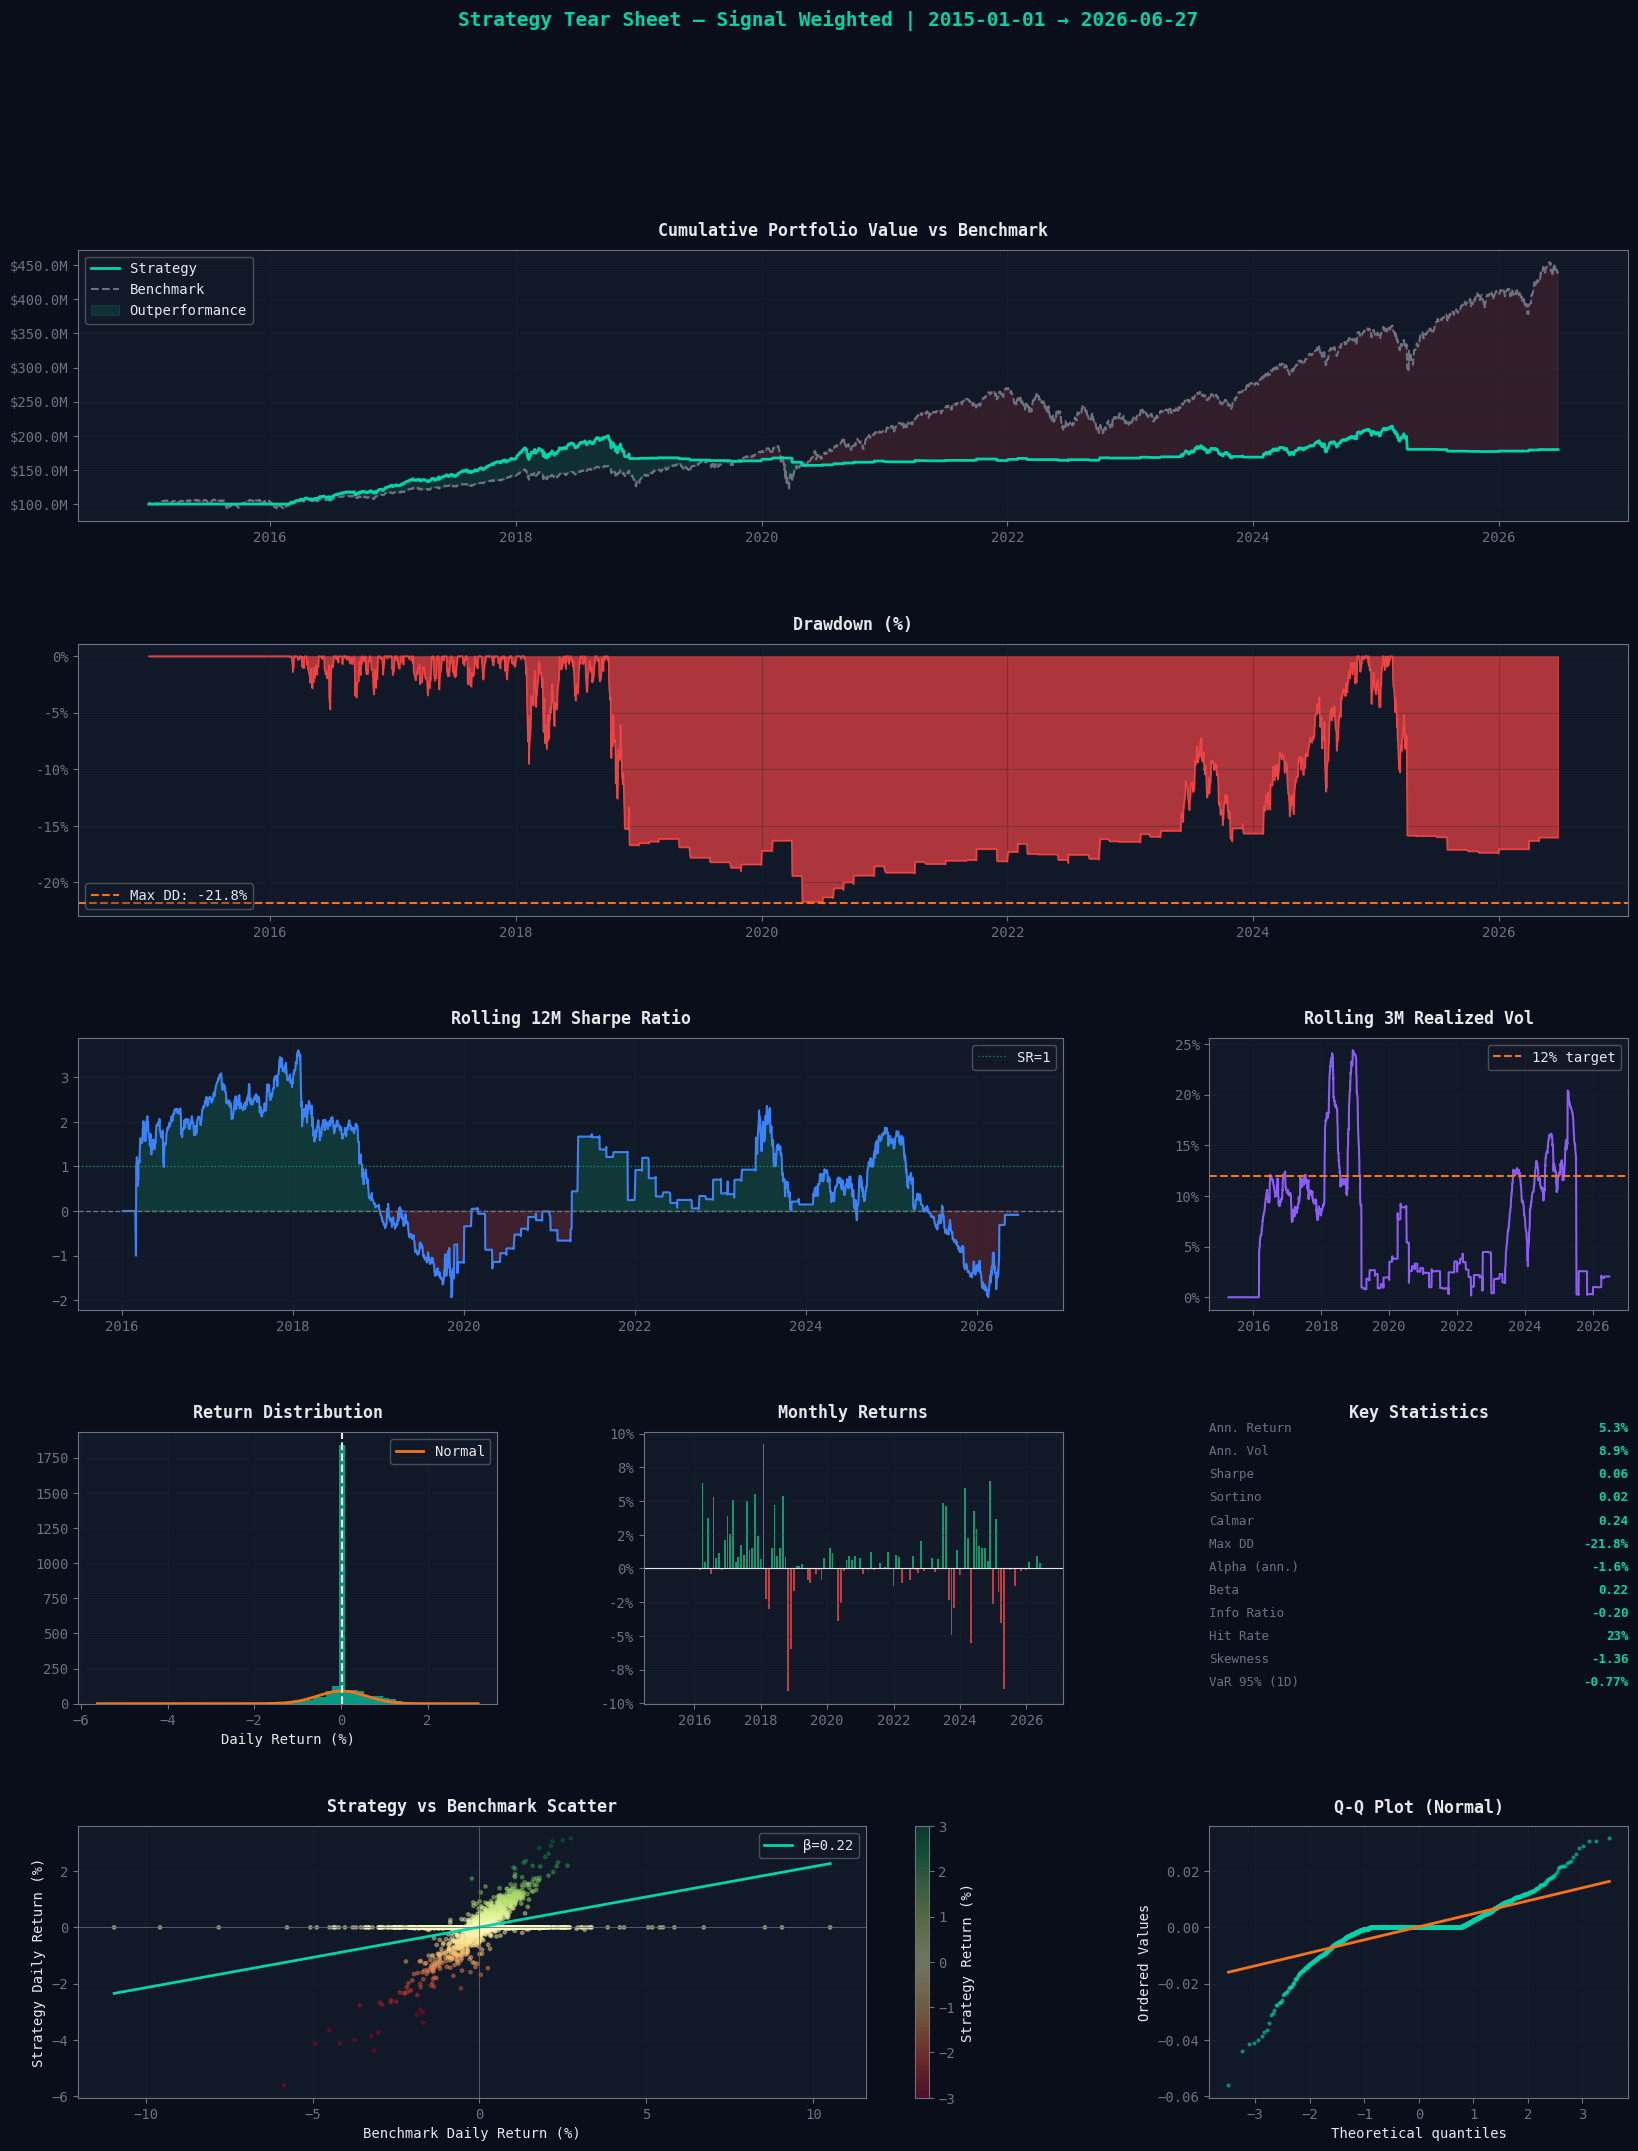

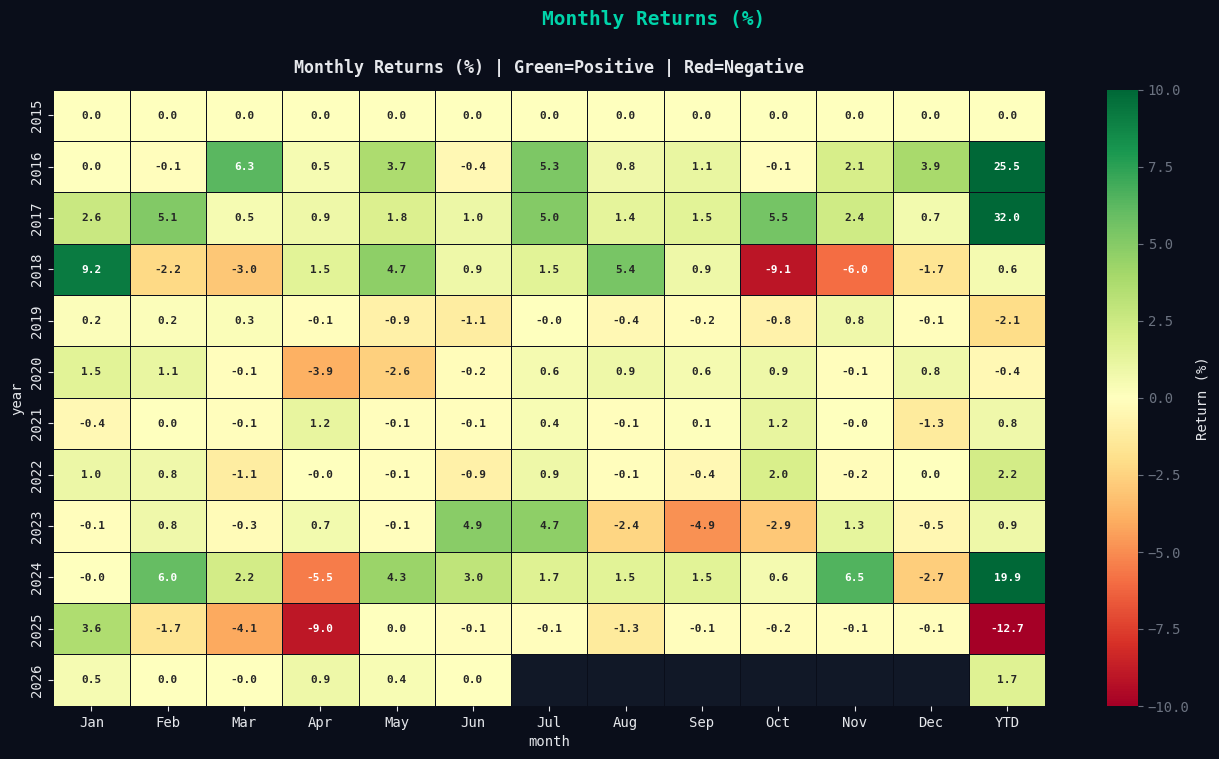

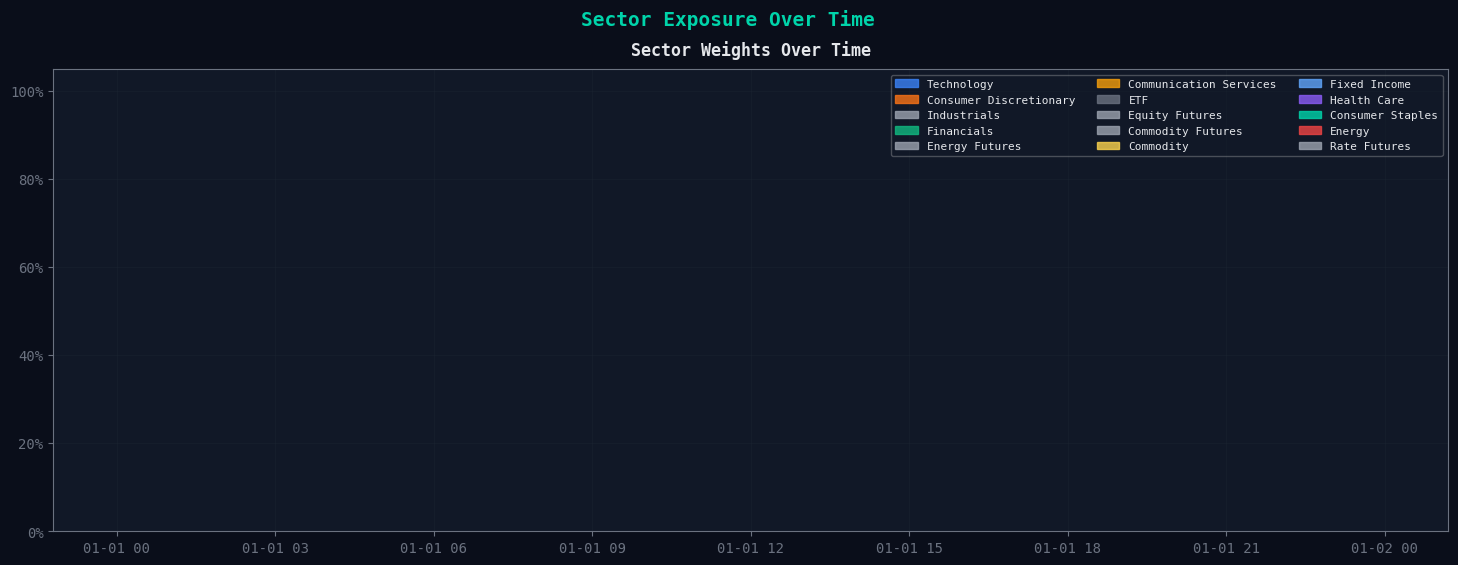

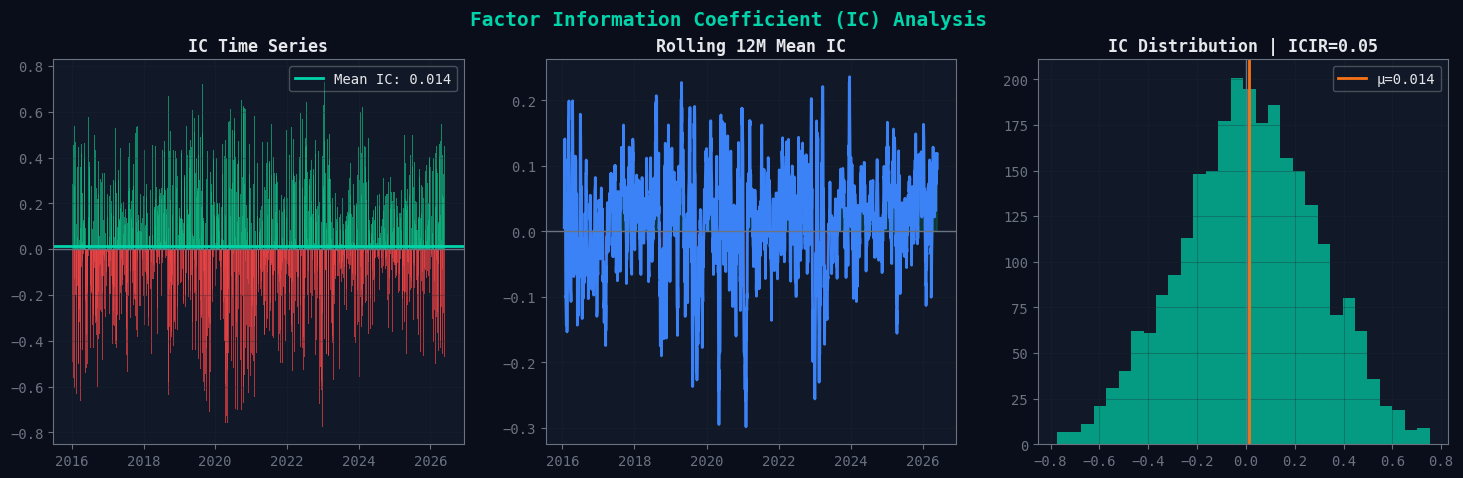

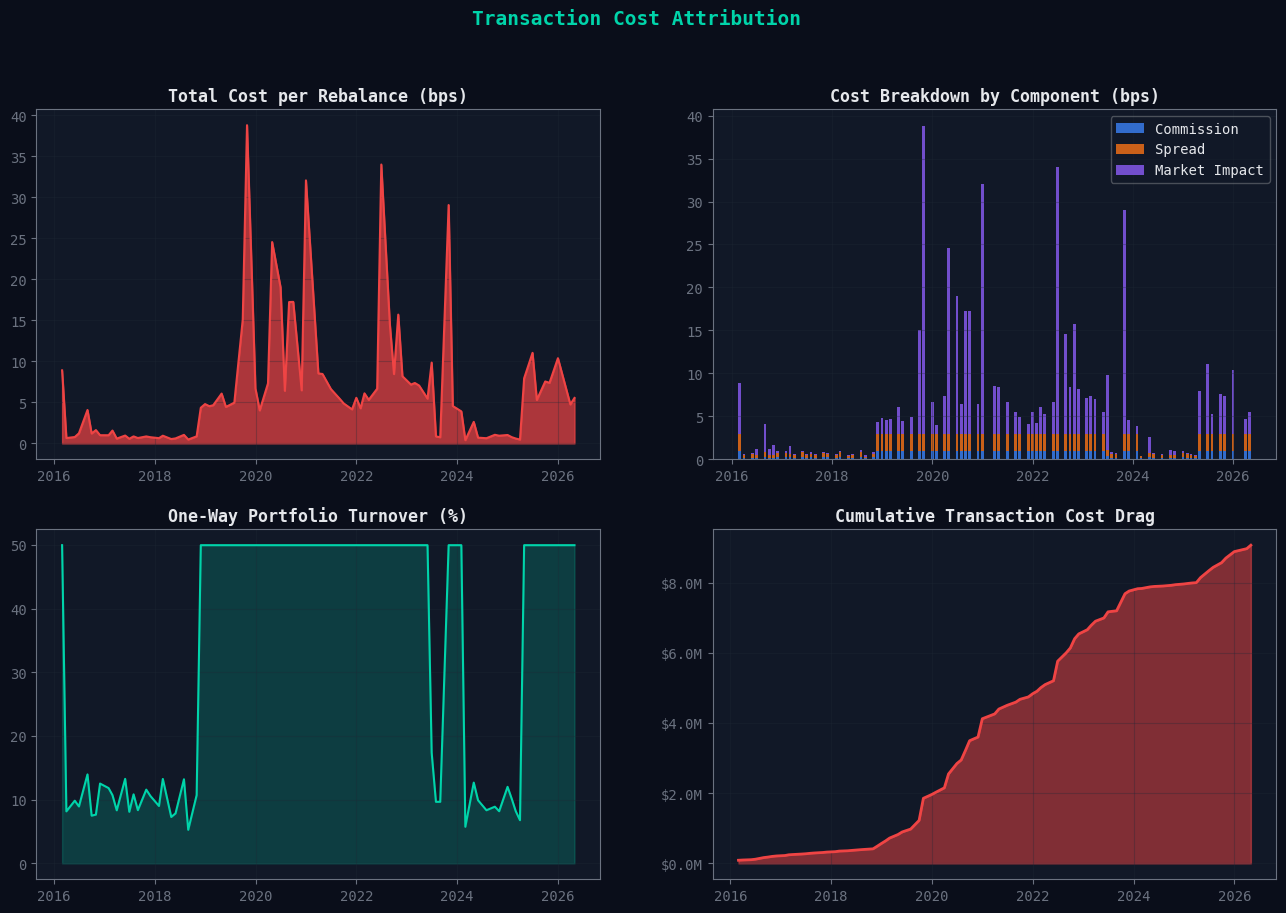

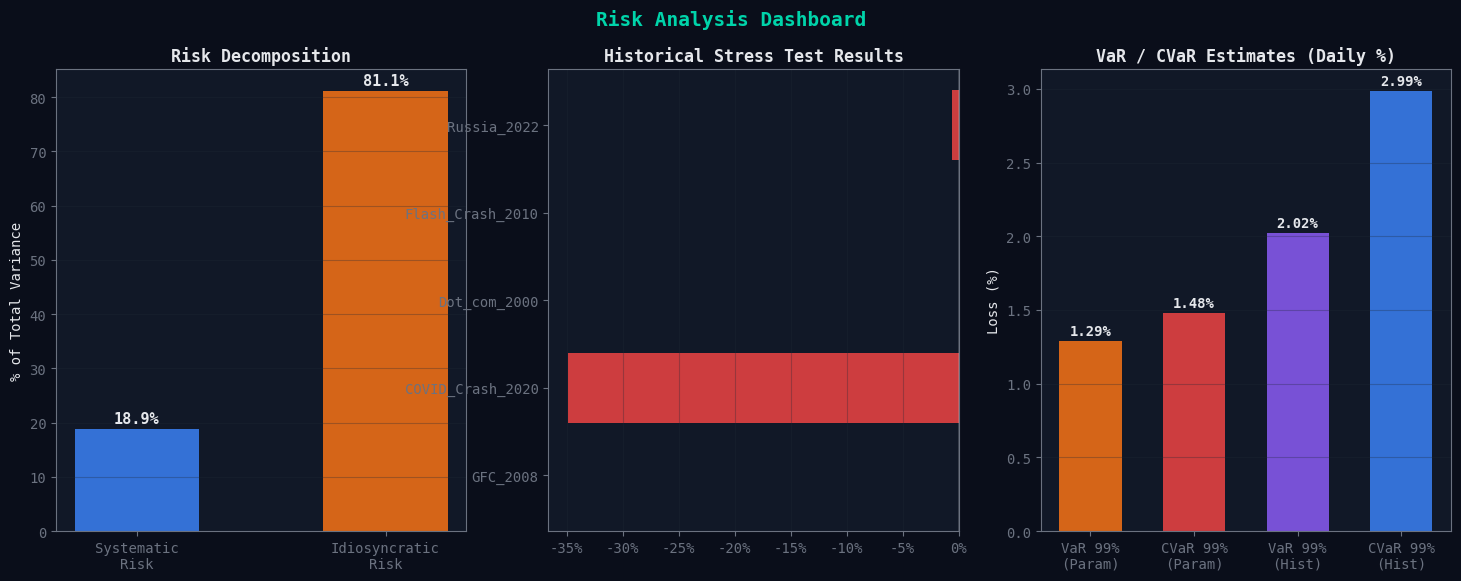

In [3]:
results = run_platform(CONFIG, method="signal_weighted")